# Pedroni Panel SVAR: Utilization × Liquidation × Volatility

**Methodology:** Pedroni (2013), *Econometrics* 1(2), 180-206  
**Key difference from pooled FE-VAR:** Estimates **heterogeneous member-specific SVARs**, decomposes shocks into common vs idiosyncratic components via Lambda matrix.  
**Identification:** Cholesky (lower-triangular), ordering: utilization → liquidation → volatility  
**Lag selection:** BIC (max 10), IRF horizon: 20 steps  
**Panel:** 30 CSUs across 10+ chains, Jan 2024 – Dec 2025

In [1]:
import sys
import os
import warnings
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')
warnings.filterwarnings('ignore', category=FutureWarning)

# Add Pedroni SVAR code to path
sys.path.insert(0, str(Path('../code/pedroni_svar').resolve()))
from SVAR import VAR_input, SVAR, VAR_output
from panelSVAR import panelSVAR, Panel_output

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 1. Load Panel Data

In [2]:
df = pd.read_parquet('../data/analysis/panel_svar_data.parquet')
print(f'Raw panel: {len(df):,} obs, {df["csu"].nunique()} CSUs')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Raw panel: 19,536 obs, 33 CSUs
Date range: 2024-07-01 to 2026-02-12
Columns: ['date', 'csu', 'n_liquidations', 'total_collateral_usd', 'total_debt_usd', 'liquidation', 'utilization', 'volatility', 'basket_return']


,date,csu,n_liquidations,total_collateral_usd,total_debt_usd,liquidation,utilization,volatility,basket_return
0,2024-07-01,aave_v3_arbitrum,3,122.313450,115.640516,4.814729,0.459038,0.013007,0.009691
1,2024-07-02,aave_v3_arbitrum,2,98.901707,91.217170,4.604187,0.463423,0.010955,-0.005447
2,2024-07-03,aave_v3_arbitrum,9,1848.640659,1750.247607,7.522747,0.464547,0.011389,-0.027323


## 2. Prepare Analysis Variables

Variables:
1. **utilization** — borrowed / supplied (leverage proxy, bounded 0–1)
2. **liquidation** — `log1p(n_liquidations)` (handles zero-liquidation days)
3. **volatility** — 14-day rolling std of collateral basket log returns

In [3]:
VARIABLE_ORDER = ['utilization', 'liquidation', 'volatility']

# Drop NaN in any analysis variable
panel = df[['date', 'csu'] + VARIABLE_ORDER].dropna(subset=VARIABLE_ORDER).copy()
print(f'Analysis panel: {len(panel):,} obs, {panel["csu"].nunique()} CSUs')
print(f'\nVariable summary:')
panel[VARIABLE_ORDER].describe().round(4)

Analysis panel: 17,117 obs, 33 CSUs

Variable summary:


,utilization,liquidation,volatility
count,17117.0000,17117.0000,17117.0000
mean,0.3764,1.8482,0.0209
std,0.2180,3.7679,0.0120
min,0.0000,0.0000,0.0000
25%,0.2695,0.0000,0.0132
50%,0.3337,0.0000,0.0189
75%,0.4345,0.0422,0.0268
max,1.0000,20.7266,0.0843


## 3. Define Subsamples

In [4]:
# === Architecture Comparison ===
# Pooled: shared liquidity pool across borrowers/collateral types
POOLED_CSUS = [
    'aave_v3_arbitrum', 'aave_v3_avalanche', 'aave_v3_base',
    'aave_v3_binance', 'aave_v3_ethereum', 'aave_v3_linea',
    'aave_v3_optimism', 'aave_v3_polygon', 'aave_v3_scroll',
    'aave_v3_xdai',
    'benqi_lending_avalanche', 'moonwell_lending_base',
    'sparklend_ethereum', 'venus_core_pool_binance',
    'fluid_lending_arbitrum',
    'compound_v2_ethereum',
    'lodestar_lending_arbitrum', 'mendi_lending_linea',
]

# Isolated: each market has its own isolated risk pool
ISOLATED_CSUS = [
    'compound_v3_arb_usdc', 'compound_v3_arb_usdc_e',
    'compound_v3_arb_usdt', 'compound_v3_arb_weth',
    'compound_v3_base_aero', 'compound_v3_base_usdc',
    'compound_v3_base_usdbc', 'compound_v3_base_weth',
    'compound_v3_eth_usdc', 'compound_v3_eth_usds',
    'compound_v3_eth_usdt', 'compound_v3_eth_weth',
]

# === Mechanism Comparison ===
# Aave-style: instant competitive liquidation (any 3rd-party can liquidate)
AAVE_STYLE_CSUS = [
    'aave_v3_arbitrum', 'aave_v3_avalanche', 'aave_v3_base',
    'aave_v3_binance', 'aave_v3_ethereum', 'aave_v3_linea',
    'aave_v3_optimism', 'aave_v3_polygon', 'aave_v3_scroll',
    'aave_v3_xdai',
    'moonwell_lending_base', 'sparklend_ethereum',
    'benqi_lending_avalanche', 'venus_core_pool_binance',
    'fluid_lending_arbitrum',
    'compound_v2_ethereum',
    'lodestar_lending_arbitrum', 'mendi_lending_linea',
]

# Compound V3 absorb model: protocol absorbs, then sells collateral
COMPOUND_V3_CSUS = ISOLATED_CSUS  # same as isolated

# === Chain Comparison ===
ETHEREUM_L1_CSUS = [
    'aave_v3_ethereum', 'compound_v2_ethereum',
    'compound_v3_eth_usdc', 'compound_v3_eth_usds',
    'compound_v3_eth_usdt', 'compound_v3_eth_weth',
    'sparklend_ethereum',
]

ARBITRUM_L2_CSUS = [
    'aave_v3_arbitrum',
    'compound_v3_arb_usdc', 'compound_v3_arb_usdc_e',
    'compound_v3_arb_usdt', 'compound_v3_arb_weth',
    'fluid_lending_arbitrum', 'lodestar_lending_arbitrum',
]

BASE_L2_CSUS = [
    'aave_v3_base', 'moonwell_lending_base',
    'compound_v3_base_aero', 'compound_v3_base_usdc',
    'compound_v3_base_usdbc', 'compound_v3_base_weth',
]

# Filter to CSUs in the analysis panel
valid_csus = set(panel['csu'].unique())
POOLED_CSUS = [c for c in POOLED_CSUS if c in valid_csus]
ISOLATED_CSUS = [c for c in ISOLATED_CSUS if c in valid_csus]
AAVE_STYLE_CSUS = [c for c in AAVE_STYLE_CSUS if c in valid_csus]
COMPOUND_V3_CSUS = [c for c in COMPOUND_V3_CSUS if c in valid_csus]
ETHEREUM_L1_CSUS = [c for c in ETHEREUM_L1_CSUS if c in valid_csus]
ARBITRUM_L2_CSUS = [c for c in ARBITRUM_L2_CSUS if c in valid_csus]
BASE_L2_CSUS = [c for c in BASE_L2_CSUS if c in valid_csus]
ALL_CSUS = panel['csu'].unique().tolist()

print('Subsamples defined:')
print(f'  All:            {len(ALL_CSUS)} CSUs')
print(f'  Pooled:         {len(POOLED_CSUS)} CSUs')
print(f'  Isolated:       {len(ISOLATED_CSUS)} CSUs')
print(f'  Aave-Style:     {len(AAVE_STYLE_CSUS)} CSUs')
print(f'  Compound V3:    {len(COMPOUND_V3_CSUS)} CSUs')
print(f'  Ethereum L1:    {len(ETHEREUM_L1_CSUS)} CSUs')
print(f'  Arbitrum L2:    {len(ARBITRUM_L2_CSUS)} CSUs')
print(f'  Base L2:        {len(BASE_L2_CSUS)} CSUs')

Subsamples defined:
  All:            33 CSUs
  Pooled:         16 CSUs
  Isolated:       12 CSUs
  Aave-Style:     16 CSUs
  Compound V3:    12 CSUs
  Ethereum L1:    7 CSUs
  Arbitrum L2:    7 CSUs
  Base L2:        6 CSUs


## 4. Summary Statistics

In [5]:
subsample_map = {
    'Full Sample': ALL_CSUS,
    'Pooled': POOLED_CSUS,
    'Isolated': ISOLATED_CSUS,
    'Aave-Style': AAVE_STYLE_CSUS,
    'Compound V3': COMPOUND_V3_CSUS,
    'Ethereum L1': ETHEREUM_L1_CSUS,
    'Arbitrum L2': ARBITRUM_L2_CSUS,
    'Base L2': BASE_L2_CSUS,
}

rows = []
for label, csus in subsample_map.items():
    sub = panel[panel['csu'].isin(csus)]
    for var in VARIABLE_ORDER:
        rows.append({
            'Subsample': label, 'Variable': var, 'N': len(sub),
            'Mean': sub[var].mean(), 'Std': sub[var].std(),
            'Min': sub[var].min(), 'Max': sub[var].max(),
        })

stats_df = pd.DataFrame(rows)
print('Table 1: Summary Statistics')
stats_df.round(4)

Table 1: Summary Statistics


,Subsample,Variable,N,Mean,Std,Min,Max
0,Full Sample,utilization,17117,0.3764,0.2180,0.0000,1.0000
1,Full Sample,liquidation,17117,1.8482,3.7679,0.0000,20.7266
2,Full Sample,volatility,17117,0.0209,0.0120,0.0000,0.0843
3,Pooled,utilization,8473,0.3902,0.1505,0.0000,1.0000
4,Pooled,liquidation,8473,3.2434,4.5176,0.0000,20.7266
5,Pooled,volatility,8473,0.0213,0.0110,0.0000,0.0635
6,Isolated,utilization,6349,0.3092,0.1235,0.0000,0.9142
7,Isolated,liquidation,6349,0.4721,2.1719,0.0000,18.0951
8,Isolated,volatility,6349,0.0225,0.0129,0.0015,0.0843
9,Aave-Style,utilization,8473,0.3902,0.1505,0.0000,1.0000


## 5. Pedroni Panel SVAR Configuration

In [6]:
# SVAR configuration
VARIABLES = {
    'utilization': [0, 0],   # stationary in, stationary out
    'liquidation': [0, 0],
    'volatility':  [0, 0],
}
SHOCKS = ['Utilization', 'Liquidation', 'Volatility']

# Cholesky: lower-triangular M -> zeros in upper triangle
SR_CONSTRAINT = np.array([
    ['.', '0', '0'],
    ['.', '.', '0'],
    ['.', '.', '.'],
])
SR_SIGN = np.array([
    ['+', '.', '.'],
    ['.', '+', '.'],
    ['.', '.', '+'],
])

MAXLAGS = 10
NSTEPS = 20
LAGMETHOD = 'bic'

def make_var_input(sub_df):
    """Create VAR_input for Pedroni SVAR."""
    return VAR_input(
        variables=copy.deepcopy(VARIABLES),
        variable_order=VARIABLE_ORDER,
        shocks=SHOCKS,
        td_col=['date'],
        member_col='csu',
        M=None,
        sr_constraint=SR_CONSTRAINT.copy(),
        lr_constraint=np.array([]),
        sr_sign=SR_SIGN.copy(),
        lr_sign=np.array([]),
        maxlags=MAXLAGS,
        nsteps=NSTEPS,
        lagmethod=LAGMETHOD,
        bootstrap=False,
        df=sub_df,
        plot=False,
        savefig_path='',
    )

def parse_panel_output(panel_out, nsteps=NSTEPS, size=3):
    """Parse Panel_output into dict of member -> {composite, common, idiosyncratic, lambda}."""
    results = {}
    for member in panel_out.comp_df.index:
        comp_row = panel_out.comp_df.loc[member]
        comm_row = panel_out.comm_df.loc[member]
        idio_row = panel_out.idio_df.loc[member]
        lam_row = panel_out.lambda_df.loc[member]
        if comp_row.isna().all():
            continue
        comp_ir = np.zeros((nsteps + 1, size, size))
        comm_ir = np.zeros((nsteps + 1, size, size))
        idio_ir = np.zeros((nsteps + 1, size, size))
        idx = 0
        for vr in range(size):
            for sk in range(size):
                for lg in range(nsteps + 1):
                    comp_ir[lg, vr, sk] = float(comp_row.iloc[idx])
                    comm_ir[lg, vr, sk] = float(comm_row.iloc[idx])
                    idio_ir[lg, vr, sk] = float(idio_row.iloc[idx])
                    idx += 1
        lam_mat = np.array(lam_row.values, dtype=float).reshape(size, size)
        results[member] = {
            'composite': comp_ir, 'common': comm_ir,
            'idiosyncratic': idio_ir, 'lambda': lam_mat,
        }
    return results

def run_pedroni(sub_df, label):
    """Run Pedroni SVAR on a subsample, return parsed member IRFs."""
    print(f'\n--- {label}: {sub_df["csu"].nunique()} members, {len(sub_df)} obs ---')
    # panelSVAR.py writes to ./output/ relative to CWD
    os.makedirs('output', exist_ok=True)
    var_input = make_var_input(sub_df)
    panel_out = panelSVAR(var_input)
    member_irfs = parse_panel_output(panel_out)
    total = sub_df['csu'].nunique()
    print(f'  Estimated: {len(member_irfs)}/{total} members')
    return member_irfs, panel_out

print('Configuration ready.')
print(f'Ordering: {" \u2192 ".join(VARIABLE_ORDER)}')
print(f'Lags: {LAGMETHOD.upper()} (max {MAXLAGS}), Steps: {NSTEPS}')

Configuration ready.
Ordering: utilization → liquidation → volatility
Lags: BIC (max 10), Steps: 20


## 6. Plotting Utilities

In [7]:
def compute_median_irf(member_irfs, irf_type='composite'):
    arrays = [v[irf_type] for v in member_irfs.values()]
    if not arrays:
        return None
    return np.median(np.stack(arrays), axis=0)

def compute_mean_irf(member_irfs, irf_type='composite'):
    arrays = [v[irf_type] for v in member_irfs.values()]
    if not arrays:
        return None
    return np.mean(np.stack(arrays), axis=0)

def compute_iqr(member_irfs, irf_type='composite'):
    arrays = [v[irf_type] for v in member_irfs.values()]
    if not arrays:
        return None, None
    stacked = np.stack(arrays)
    return np.percentile(stacked, 25, axis=0), np.percentile(stacked, 75, axis=0)

# Distinct color palette for member lines (expanded for 30 CSUs)
MEMBER_COLORS = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
    '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990',
    '#dcbeff', '#9A6324', '#800000', '#aaffc3', '#808000',
    '#ffd8b1', '#000075', '#a9a9a9', '#e6beff', '#fffac8',
    '#1abc9c', '#e74c3c', '#2980b9', '#f39c12', '#8e44ad',
    '#16a085', '#c0392b', '#2c3e50', '#d35400', '#7f8c8d',
]

def plot_member_irfs(member_irfs, title, irf_type='composite', save_path=None):
    """Plot all member IRFs overlaid with median highlighted."""
    size = len(VARIABLE_ORDER)
    median_ir = compute_median_irf(member_irfs, irf_type)
    if median_ir is None:
        print(f'No members to plot for {title}')
        return
    fig, axes = plt.subplots(size, size, figsize=(5*size, 3.5*size), sharex=True)
    steps = np.arange(median_ir.shape[0])
    members_list = list(member_irfs.keys())
    for i, var in enumerate(VARIABLE_ORDER):
        for j, shock in enumerate(SHOCKS):
            ax = axes[i, j]
            for k, (member, data) in enumerate(member_irfs.items()):
                short = member.replace('compound_v3_', 'c3_').replace('aave_v3_', 'a3_').replace('_lending_', '_').replace('_core_pool_', '_')
                color = MEMBER_COLORS[k % len(MEMBER_COLORS)]
                ax.plot(steps, data[irf_type][:, i, j], color=color,
                        alpha=0.85, linewidth=1.4, label=short)
            # Median: dashed black, thinner, drawn on top
            ax.plot(steps, median_ir[:, i, j], 'k--', linewidth=2.0,
                    alpha=0.7, label='Median', zorder=10)
            ax.axhline(0, color='black', linestyle=':', linewidth=0.5)
            ax.set_title(f'{shock} \u2192 {var} (\u03c3)', fontsize=10)
            if i == size-1:
                ax.set_xlabel('Steps')
    # Legend on first subplot
    axes[0, 0].legend(fontsize=6, loc='best', framealpha=0.8, ncol=2)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_comparison_irfs(label_a, irfs_a, label_b, irfs_b, title, save_path=None):
    """Plot median composite IRFs for two subsamples with IQR bands."""
    size = len(VARIABLE_ORDER)
    med_a = compute_median_irf(irfs_a)
    med_b = compute_median_irf(irfs_b)
    iqr_a_lo, iqr_a_hi = compute_iqr(irfs_a)
    iqr_b_lo, iqr_b_hi = compute_iqr(irfs_b)
    if med_a is None or med_b is None:
        print(f'Cannot plot comparison: missing data')
        return
    fig, axes = plt.subplots(size, size, figsize=(5*size, 3.5*size), sharex=True)
    steps = np.arange(med_a.shape[0])
    for i, var in enumerate(VARIABLE_ORDER):
        for j, shock in enumerate(SHOCKS):
            ax = axes[i, j]
            ax.plot(steps, med_a[:, i, j], color='#2176AE', linewidth=2.2,
                    label=label_a, marker='o', markersize=2.5, markevery=3)
            ax.plot(steps, med_b[:, i, j], color='#D7263D', linewidth=2.2,
                    linestyle='--', label=label_b, marker='s', markersize=2.5, markevery=3)
            if iqr_a_lo is not None:
                ax.fill_between(steps, iqr_a_lo[:, i, j], iqr_a_hi[:, i, j],
                                alpha=0.18, color='#2176AE')
            if iqr_b_lo is not None:
                ax.fill_between(steps, iqr_b_lo[:, i, j], iqr_b_hi[:, i, j],
                                alpha=0.18, color='#D7263D')
            ax.axhline(0, color='black', linestyle=':', linewidth=0.5)
            ax.set_title(f'{shock} \u2192 {var} (\u03c3)', fontsize=10)
            if i == 0 and j == 0:
                ax.legend(fontsize=9)
            if i == size-1:
                ax.set_xlabel('Steps')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_decomposition(member_irfs, member_name, save_path=None):
    """Plot composite vs common vs idiosyncratic IRFs for one member."""
    if member_name not in member_irfs:
        print(f'{member_name} not found')
        return
    data = member_irfs[member_name]
    size = len(VARIABLE_ORDER)
    fig, axes = plt.subplots(size, size, figsize=(5*size, 3.5*size), sharex=True)
    steps = np.arange(data['composite'].shape[0])
    for i, var in enumerate(VARIABLE_ORDER):
        for j, shock in enumerate(SHOCKS):
            ax = axes[i, j]
            ax.plot(steps, data['composite'][:, i, j], 'k-', linewidth=2, label='Composite')
            ax.plot(steps, data['common'][:, i, j], color='#2176AE', linestyle='--',
                    linewidth=1.8, label='Common')
            ax.plot(steps, data['idiosyncratic'][:, i, j], color='#D7263D', linestyle=':',
                    linewidth=1.8, label='Idiosyncratic')
            ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)
            ax.set_title(f'{shock} \u2192 {var} (\u03c3)', fontsize=10)
            if i == 0 and j == 0:
                ax.legend(fontsize=8)
    fig.suptitle(f'Shock Decomposition: {member_name}', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('Plotting utilities defined.')

Plotting utilities defined.


---
## 7. Full Sample: Pedroni Panel SVAR

In [8]:
full_irfs, full_out = run_pedroni(panel, 'Full Sample')


--- Full Sample: 33 members, 17117 obs ---


Transformation matrix M:
[[ 0.12826787  0.          0.        ]
 [-0.04303741  0.38451617  0.        ]
 [-0.00919588  0.03213408  0.25395844]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library

/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/

...

SVAR failed for compound_v3_base_weth: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been prov

SVAR failed for gearbox_ethereum: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.
SVAR failed for sonne_lending_optimism: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(i

  Estimated: 29/33 members


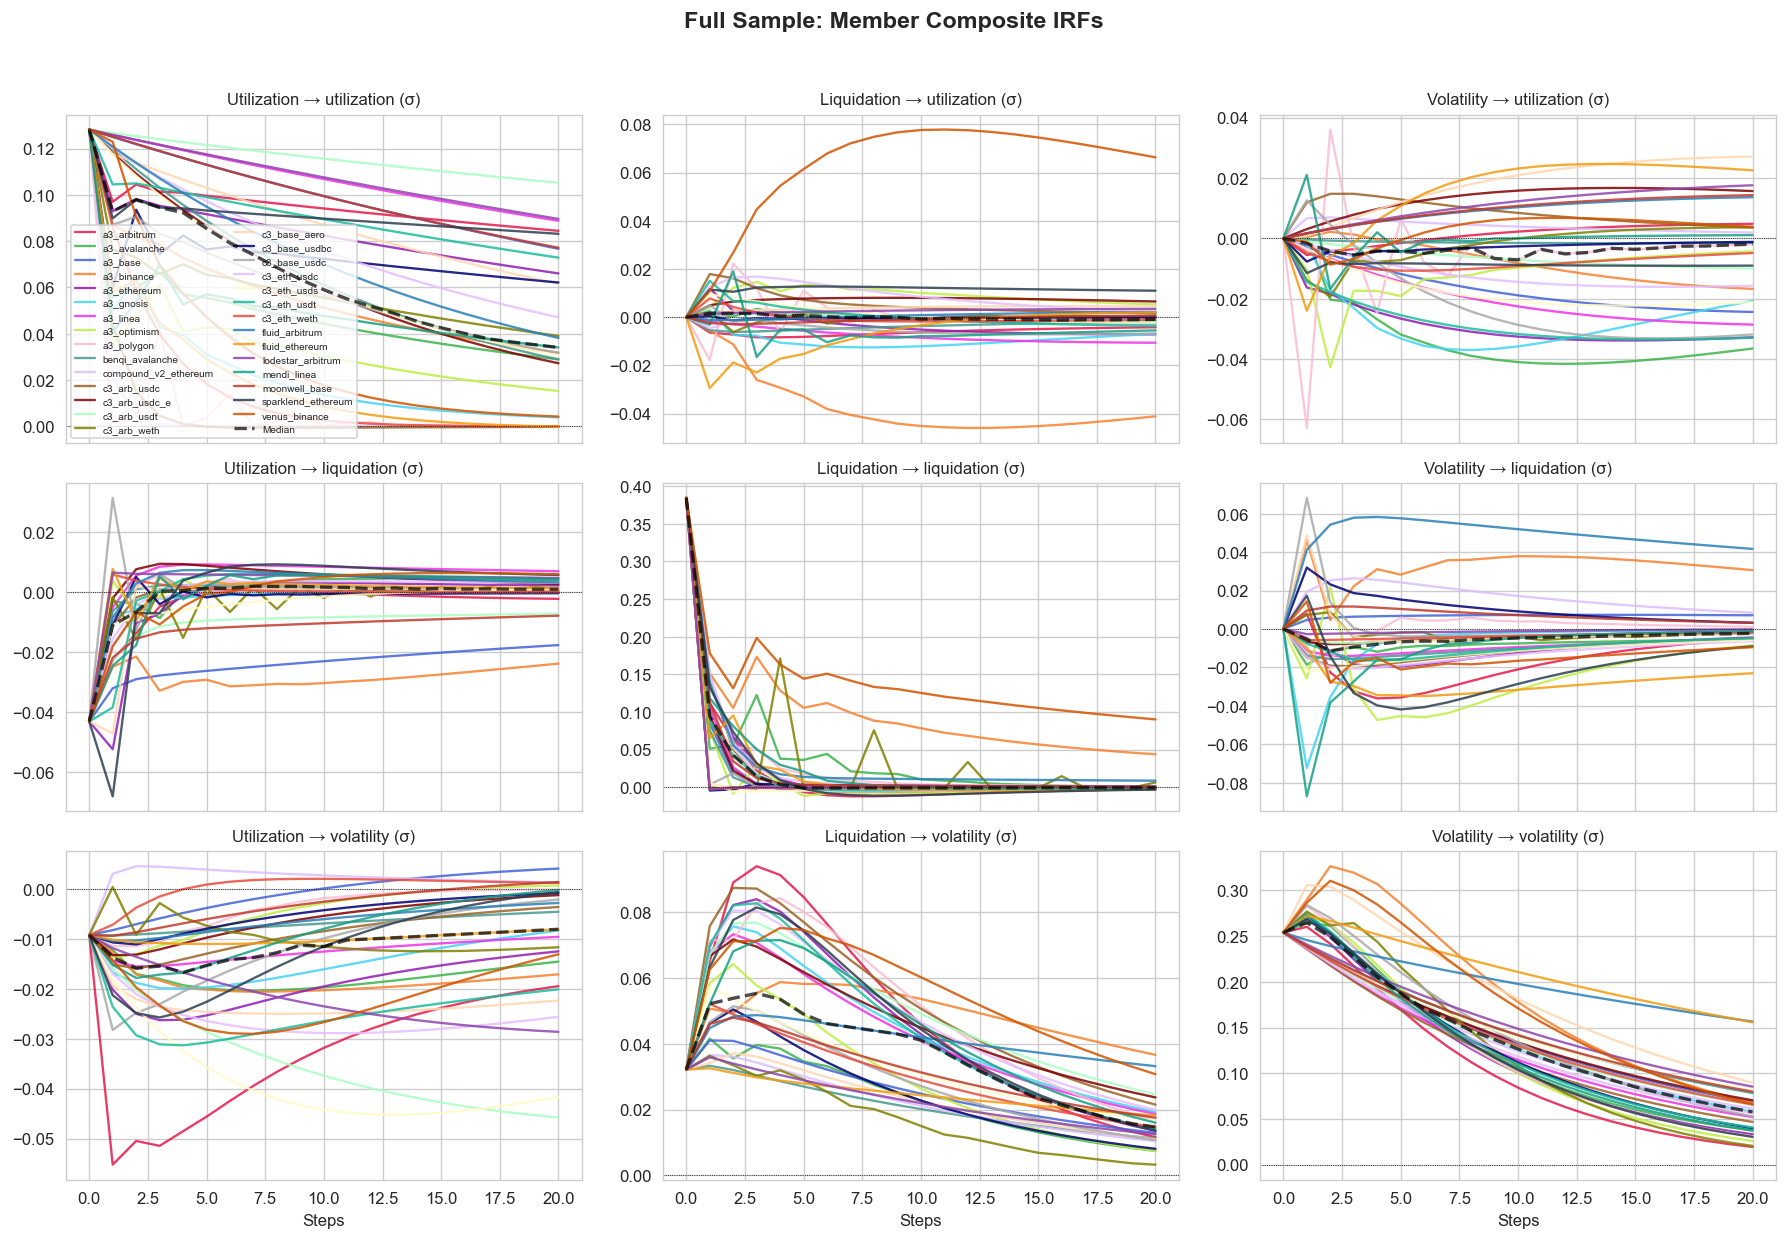

In [9]:
plot_member_irfs(full_irfs, 'Full Sample: Member Composite IRFs',
                 save_path='../results/pedroni/1st_order/full_sample_members.png')

### 7a. Shock Decomposition — Example Member

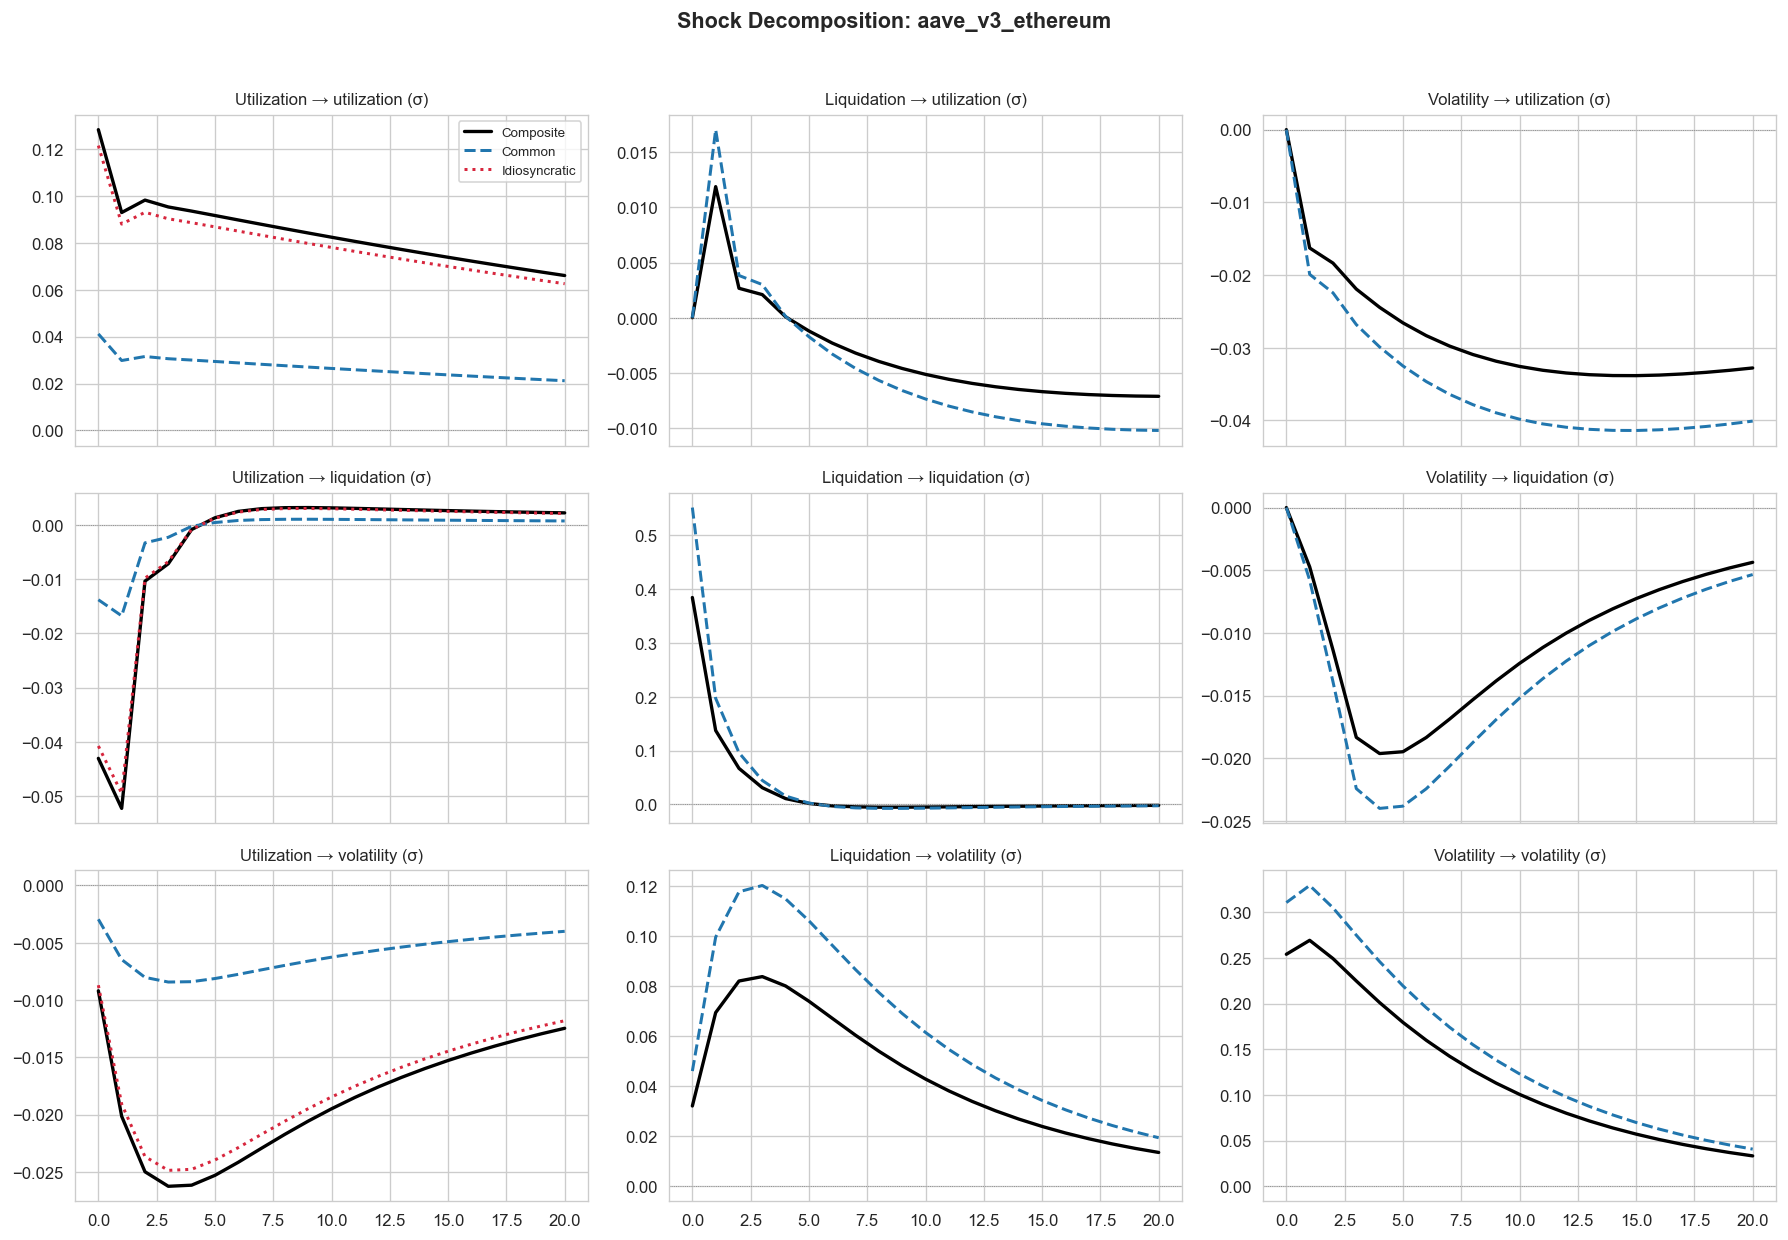

In [10]:
# Show decomposition for a representative member
example_member = 'aave_v3_ethereum' if 'aave_v3_ethereum' in full_irfs else list(full_irfs.keys())[0]
plot_decomposition(full_irfs, example_member,
                   save_path='../results/pedroni/1st_order/decomposition_example.png')

### 7b. Lambda Decomposition — Full Sample

In [11]:
def lambda_table(member_irfs, label=''):
    rows = []
    for member, data in member_irfs.items():
        lam = data['lambda']
        rows.append({
            'Member': member,
            '\u03bb_util': lam[0, 0],
            '\u03bb_liq': lam[1, 1],
            '\u03bb_vol': lam[2, 2],
        })
    ldf = pd.DataFrame(rows)
    # Add summary row
    summary = pd.DataFrame([{
        'Member': 'MEDIAN',
        '\u03bb_util': ldf['\u03bb_util'].median(),
        '\u03bb_liq': ldf['\u03bb_liq'].median(),
        '\u03bb_vol': ldf['\u03bb_vol'].median(),
    }])
    ldf = pd.concat([ldf, summary], ignore_index=True)
    return ldf

print('Table 2: Lambda Decomposition (diagonal) \u2014 Full Sample')
print('\u03bb close to 1 = driven by common shocks; close to 0 = idiosyncratic')
lambda_table(full_irfs).round(4)

Table 2: Lambda Decomposition (diagonal) — Full Sample
λ close to 1 = driven by common shocks; close to 0 = idiosyncratic


,Member,λ_util,λ_liq,λ_vol
0,aave_v3_arbitrum,0.3652,1.4586,1.1711
1,aave_v3_avalanche,1.1781,0.2656,1.0683
2,aave_v3_base,0.2211,0.8054,1.2113
3,aave_v3_binance,0.4914,0.5815,0.4924
4,aave_v3_ethereum,0.3210,1.4347,1.2230
5,aave_v3_gnosis,2.2146,1.4301,0.8987
6,aave_v3_linea,0.1291,1.7359,1.0304
7,aave_v3_optimism,1.0920,1.2268,1.3010
8,aave_v3_polygon,1.8968,1.5986,1.0812
9,benqi_lending_avalanche,0.5789,0.3060,0.9822


### 7c. Cumulative IRF Summary — Full Sample

In [12]:
def cumulative_irf_table(member_irfs, horizons=[5, 10, 20], label=''):
    median_ir = compute_median_irf(member_irfs)
    if median_ir is None:
        return pd.DataFrame()
    rows = []
    for h in horizons:
        cum = median_ir[:h+1].sum(axis=0)
        for i, var in enumerate(VARIABLE_ORDER):
            for j, shock in enumerate(SHOCKS):
                rows.append({
                    'Subsample': label,
                    'Horizon': h,
                    'Response': var,
                    'Shock': shock,
                    'Cumulative IRF': cum[i, j],
                })
    return pd.DataFrame(rows)

print('Table 3: Cumulative IRFs (Median across members) \u2014 Full Sample')
cum_full = cumulative_irf_table(full_irfs, label='Full Sample')
cum_full.pivot_table(index=['Response', 'Shock'], columns='Horizon', values='Cumulative IRF').round(6)

Table 3: Cumulative IRFs (Median across members) — Full Sample


Horizon                        5         10        20
Response    Shock                                    
liquidation Liquidation  0.539302  0.535052  0.529086
            Utilization -0.058527 -0.049923 -0.038888
            Volatility  -0.040644 -0.068563 -0.101114
utilization Liquidation  0.005945  0.005340 -0.004026
            Utilization  0.591501  0.935900  1.363049
            Volatility  -0.020009 -0.045780 -0.078598
volatility  Liquidation  0.295845  0.514944  0.754264
            Utilization -0.086185 -0.149492 -0.240751
            Volatility   1.388160  2.128034  2.969919

---
## 8. Architecture Comparison: Pooled vs Isolated

In [13]:
pooled_irfs, pooled_out = run_pedroni(panel[panel['csu'].isin(POOLED_CSUS)], 'Pooled')
isolated_irfs, isolated_out = run_pedroni(panel[panel['csu'].isin(ISOLATED_CSUS)], 'Isolated')


--- Pooled: 16 members, 8473 obs ---
Transformation matrix M:
[[0.13973792 0.         0.        ]
 [0.00640551 0.38554733 0.        ]
 [0.0070339  0.02208524 0.24897095]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred freque

...

/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/p

SVAR failed for compound_v3_base_weth: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/

  Estimated: 11/12 members


### 8a. Member IRFs — Pooled

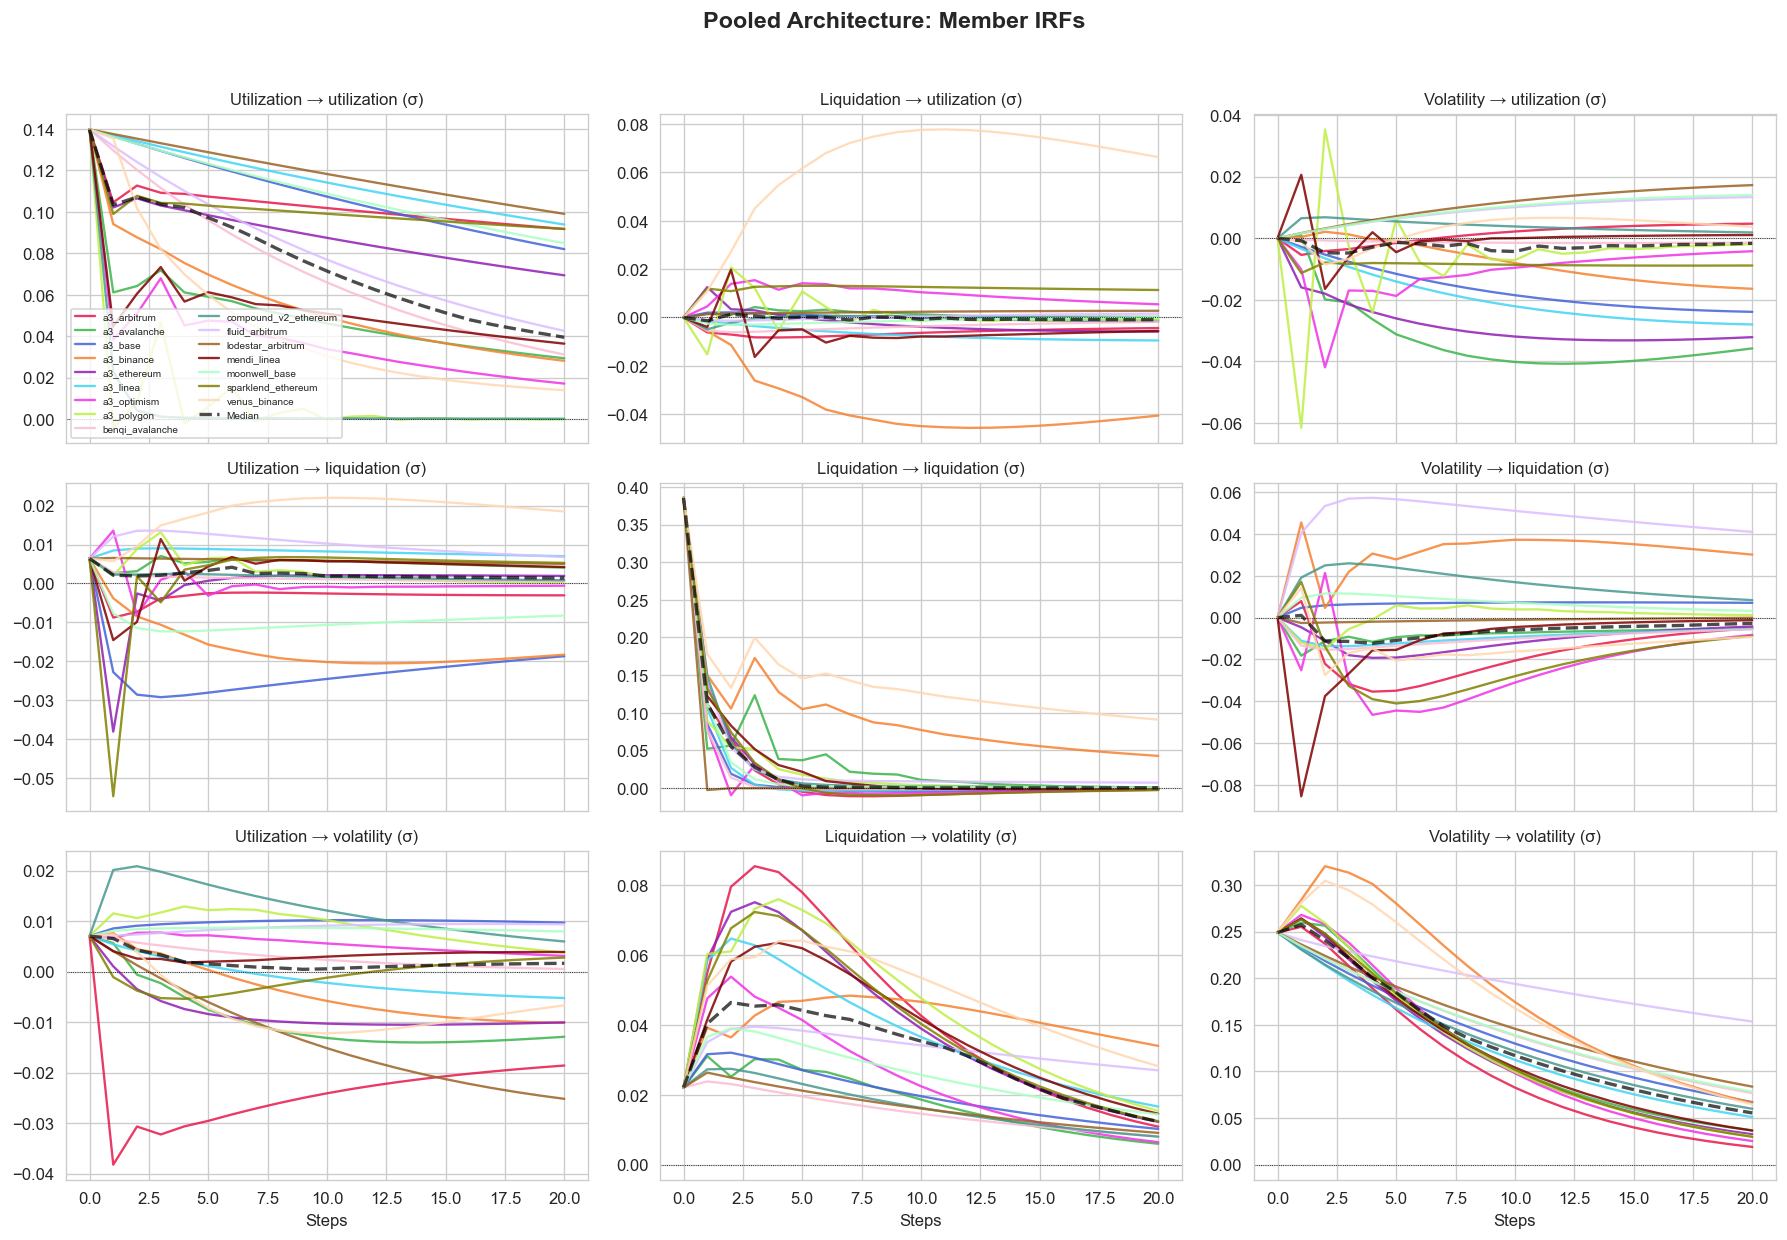

In [14]:
plot_member_irfs(pooled_irfs, 'Pooled Architecture: Member IRFs',
                 save_path='../results/pedroni/2nd_order/architecture/pooled_members.png')

### 8b. Member IRFs — Isolated

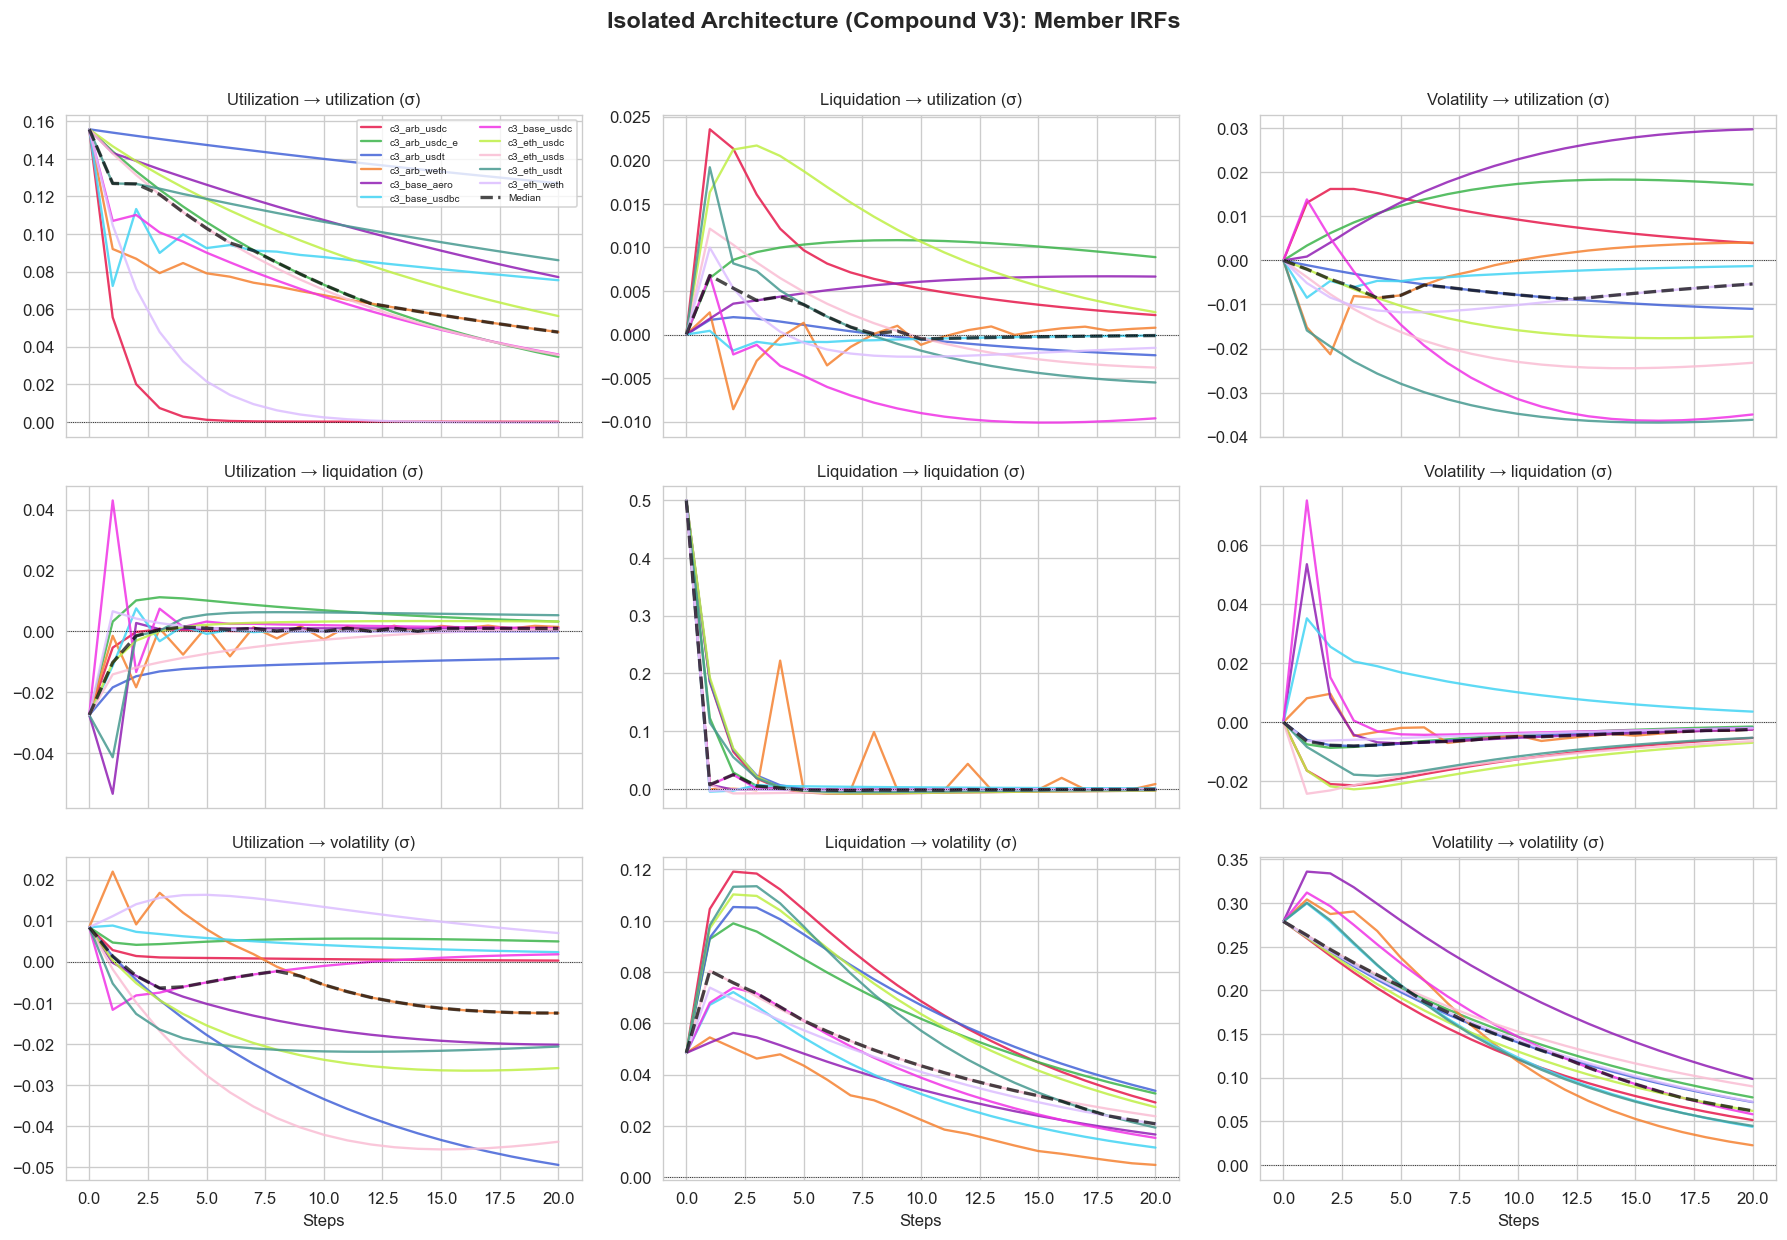

In [15]:
plot_member_irfs(isolated_irfs, 'Isolated Architecture (Compound V3): Member IRFs',
                 save_path='../results/pedroni/2nd_order/architecture/isolated_members.png')

### 8c. Comparison: Median Composite IRFs

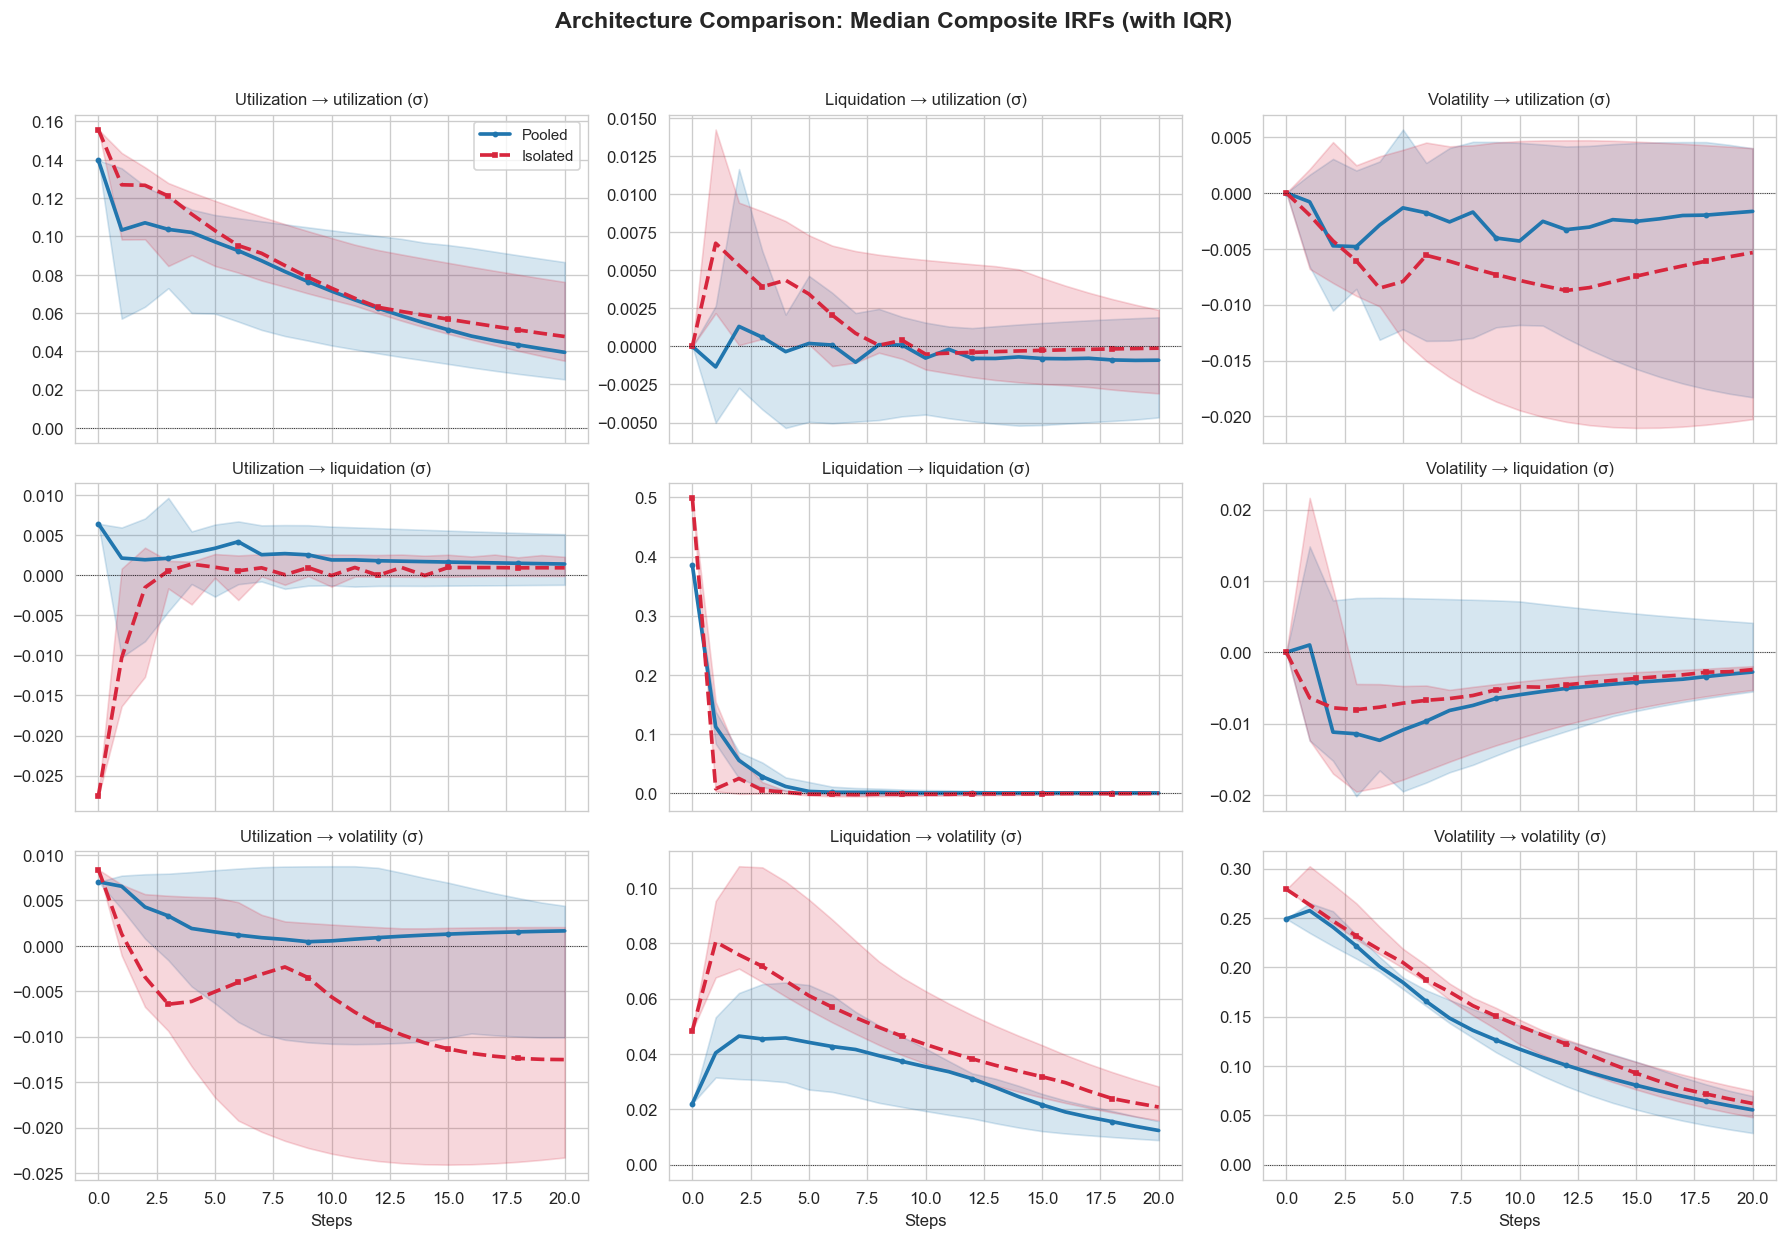

In [16]:
plot_comparison_irfs('Pooled', pooled_irfs, 'Isolated', isolated_irfs,
                     'Architecture Comparison: Median Composite IRFs (with IQR)',
                     save_path='../results/pedroni/2nd_order/architecture/architecture_comparison.png')

### 8d. Lambda Decomposition — by Architecture

In [17]:
print('Table 4: Lambda Decomposition \u2014 Pooled')
display(lambda_table(pooled_irfs).round(4))

print('\nTable 5: Lambda Decomposition \u2014 Isolated')
display(lambda_table(isolated_irfs).round(4))

Table 4: Lambda Decomposition — Pooled


,Member,λ_util,λ_liq,λ_vol
0,aave_v3_arbitrum,0.2384,1.5249,1.1765
1,aave_v3_avalanche,1.3939,0.4661,1.1330
2,aave_v3_base,0.2954,0.9864,1.2245
3,aave_v3_binance,0.5455,0.6601,0.5681
4,aave_v3_ethereum,0.1682,1.4533,1.2331
5,aave_v3_linea,0.2105,1.5342,1.0605
6,aave_v3_optimism,1.2475,1.3459,1.3292
7,aave_v3_polygon,2.8370,1.5984,1.0938
8,benqi_lending_avalanche,0.5685,0.5270,1.0326
9,compound_v2_ethereum,2.7955,0.8857,0.3140



Table 5: Lambda Decomposition — Isolated


,Member,λ_util,λ_liq,λ_vol
0,compound_v3_arb_usdc,2.8887,1.3962,1.1017
1,compound_v3_arb_usdc_e,0.8759,1.2000,0.8946
2,compound_v3_arb_usdt,0.0640,1.3071,0.7928
3,compound_v3_arb_weth,0.0935,0.2550,1.1093
4,compound_v3_base_aero,0.0115,0.2780,0.6435
5,compound_v3_base_usdbc,0.3759,0.7886,1.1748
6,compound_v3_base_usdc,1.1335,0.7812,1.0105
7,compound_v3_eth_usdc,0.7385,1.3155,1.0216
8,compound_v3_eth_usds,0.7100,1.1682,0.6518
9,compound_v3_eth_usdt,0.5347,1.3858,1.0411


### 8e. Cumulative IRF Comparison — Architecture

In [18]:
cum_pooled = cumulative_irf_table(pooled_irfs, label='Pooled')
cum_iso = cumulative_irf_table(isolated_irfs, label='Isolated')
cum_arch = pd.concat([cum_pooled, cum_iso])

print('Table 6: Cumulative IRF Comparison \u2014 Architecture (h=10)')
arch_h10 = cum_arch[cum_arch['Horizon'] == 10].pivot_table(
    index=['Response', 'Shock'], columns='Subsample', values='Cumulative IRF'
)
arch_h10['Ratio (Pooled/Isolated)'] = arch_h10['Pooled'] / arch_h10['Isolated']
arch_h10.round(6)

Table 6: Cumulative IRF Comparison — Architecture (h=10)


Subsample                Isolated    Pooled  Ratio (Pooled/Isolated)
Response    Shock                                                   
liquidation Liquidation  0.525287  0.599195                 1.140699
            Utilization -0.034180  0.032386                -0.947522
            Volatility  -0.066320 -0.082423                 1.242804
utilization Liquidation  0.026651 -0.001119                -0.041971
            Utilization  1.168079  1.062386                 0.909516
            Volatility  -0.062372 -0.028989                 0.464777
volatility  Liquidation  0.653280  0.440576                 0.674406
            Utilization -0.030003  0.028284                -0.942702
            Volatility   2.257323  2.046767                 0.906723

### 8f. Key Cross-Variable IRFs — Architecture

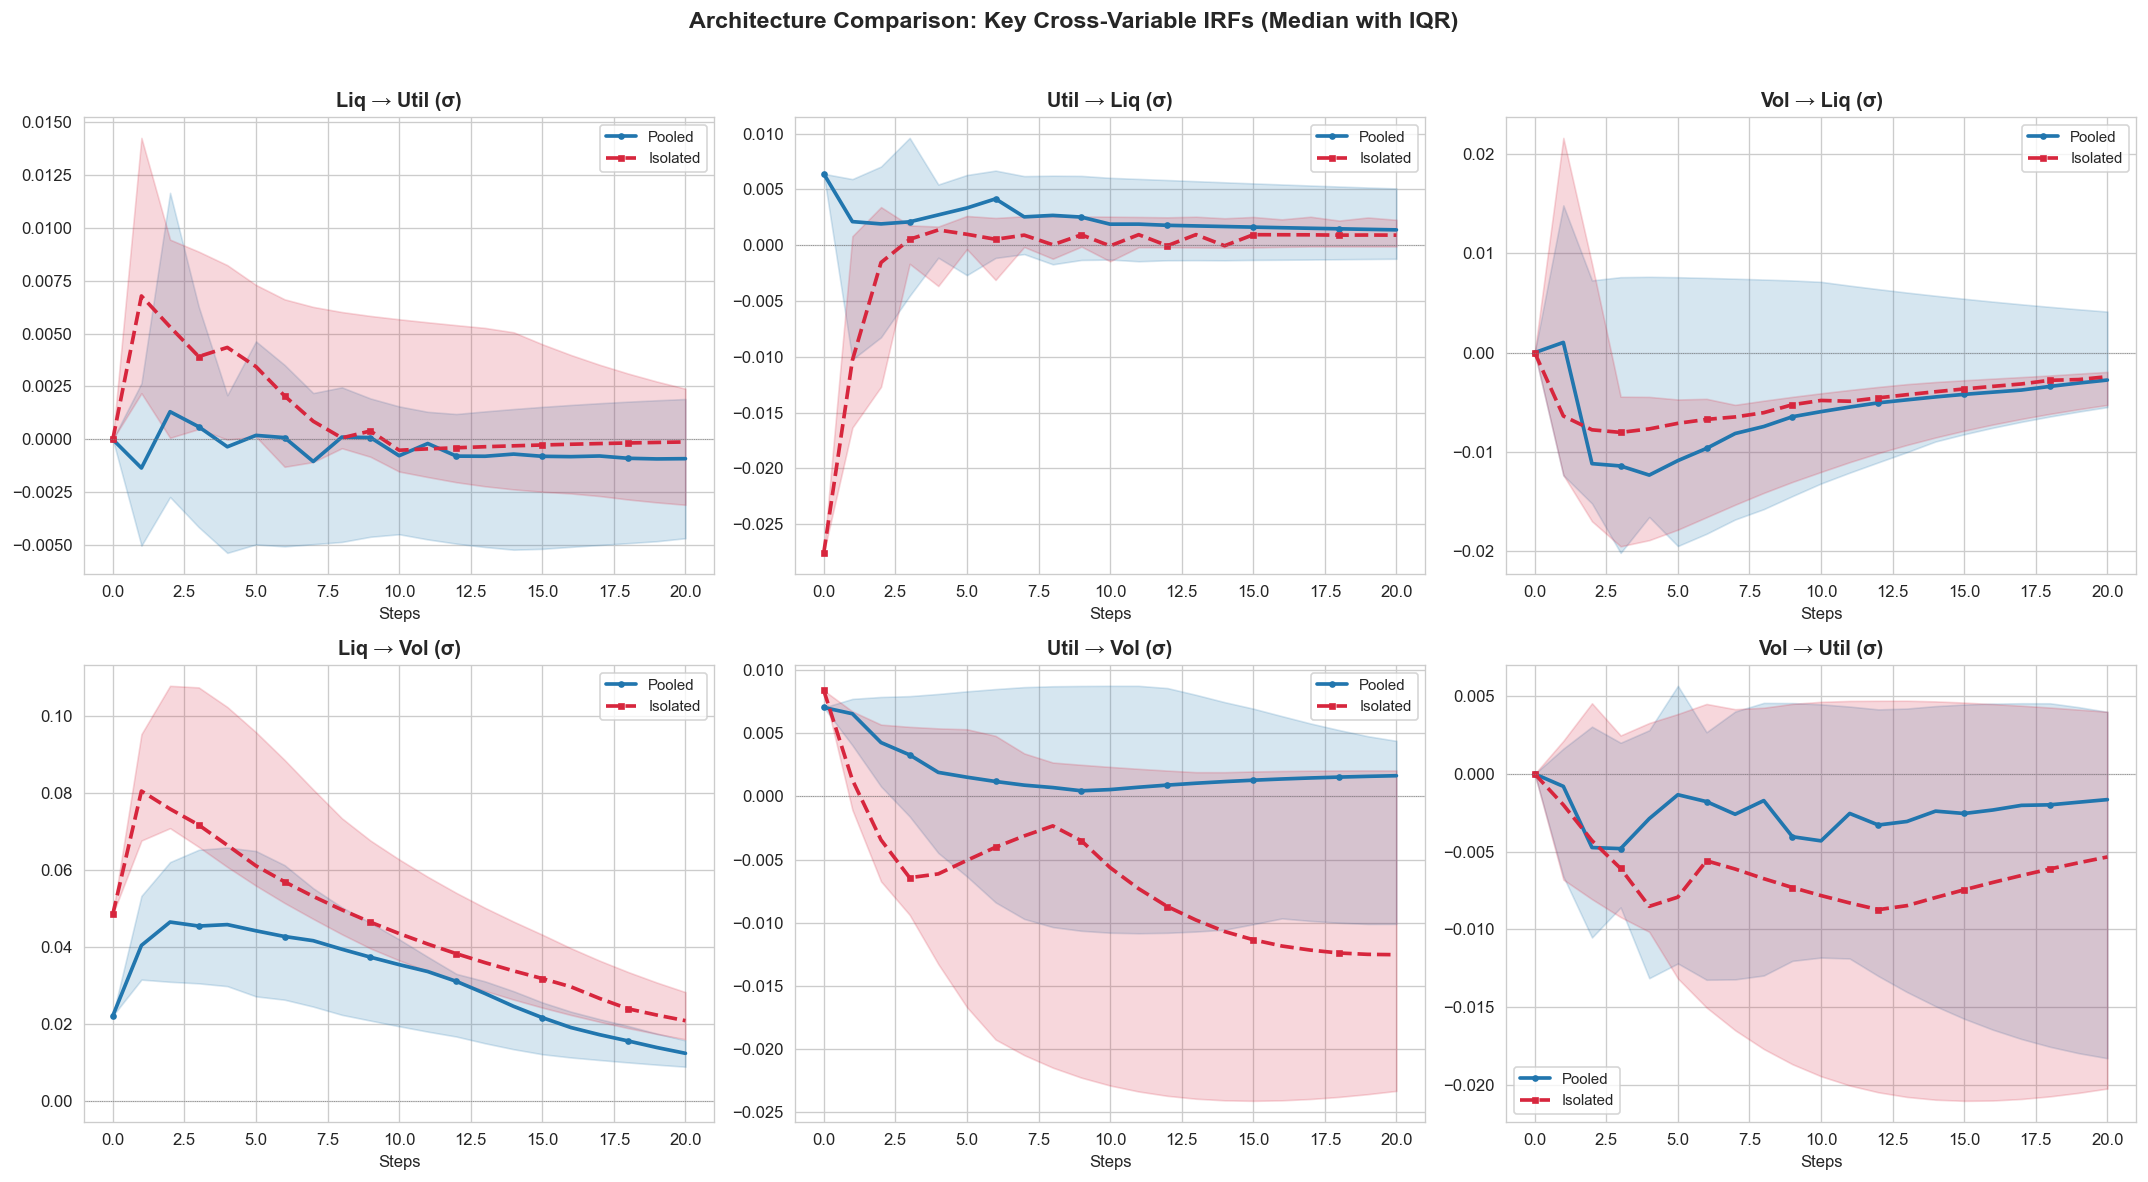

In [19]:
# Focus on key cross-variable paths
key_paths = [
    ('utilization', 'Liquidation', 0, 1, 'Liq \u2192 Util (\u03c3)'),
    ('liquidation', 'Utilization', 1, 0, 'Util \u2192 Liq (\u03c3)'),
    ('liquidation', 'Volatility', 1, 2, 'Vol \u2192 Liq (\u03c3)'),
    ('volatility', 'Liquidation', 2, 1, 'Liq \u2192 Vol (\u03c3)'),
    ('volatility', 'Utilization', 2, 0, 'Util \u2192 Vol (\u03c3)'),
    ('utilization', 'Volatility', 0, 2, 'Vol \u2192 Util (\u03c3)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
med_p = compute_median_irf(pooled_irfs)
med_i = compute_median_irf(isolated_irfs)
iqr_p_lo, iqr_p_hi = compute_iqr(pooled_irfs)
iqr_i_lo, iqr_i_hi = compute_iqr(isolated_irfs)
steps = np.arange(med_p.shape[0])

for idx, (resp, shock, ri, si, label) in enumerate(key_paths):
    ax = axes[idx // 3, idx % 3]
    ax.plot(steps, med_p[:, ri, si], color='#2176AE', linewidth=2.2,
            label='Pooled', marker='o', markersize=3, markevery=3)
    ax.plot(steps, med_i[:, ri, si], color='#D7263D', linewidth=2.2,
            linestyle='--', label='Isolated', marker='s', markersize=3, markevery=3)
    if iqr_p_lo is not None:
        ax.fill_between(steps, iqr_p_lo[:, ri, si], iqr_p_hi[:, ri, si],
                         alpha=0.18, color='#2176AE')
    if iqr_i_lo is not None:
        ax.fill_between(steps, iqr_i_lo[:, ri, si], iqr_i_hi[:, ri, si],
                         alpha=0.18, color='#D7263D')
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Steps')

fig.suptitle('Architecture Comparison: Key Cross-Variable IRFs (Median with IQR)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../results/pedroni/2nd_order/architecture/architecture_key_irfs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Mechanism Comparison: Aave-Style vs Compound V3

In [20]:
aave_irfs, aave_out = run_pedroni(panel[panel['csu'].isin(AAVE_STYLE_CSUS)], 'Aave-Style')
comp_irfs, comp_out = run_pedroni(panel[panel['csu'].isin(COMPOUND_V3_CSUS)], 'Compound V3')


--- Aave-Style: 16 members, 8473 obs ---
Transformation matrix M:
[[0.13973792 0.         0.        ]
 [0.00640551 0.38554733 0.        ]
 [0.0070339  0.02208524 0.24897095]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis

/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library

/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/l

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred freque

...

/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._i

SVAR failed for compound_v3_base_weth: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/

  Estimated: 11/12 members


/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))


### 9a. Member IRFs — Aave-Style

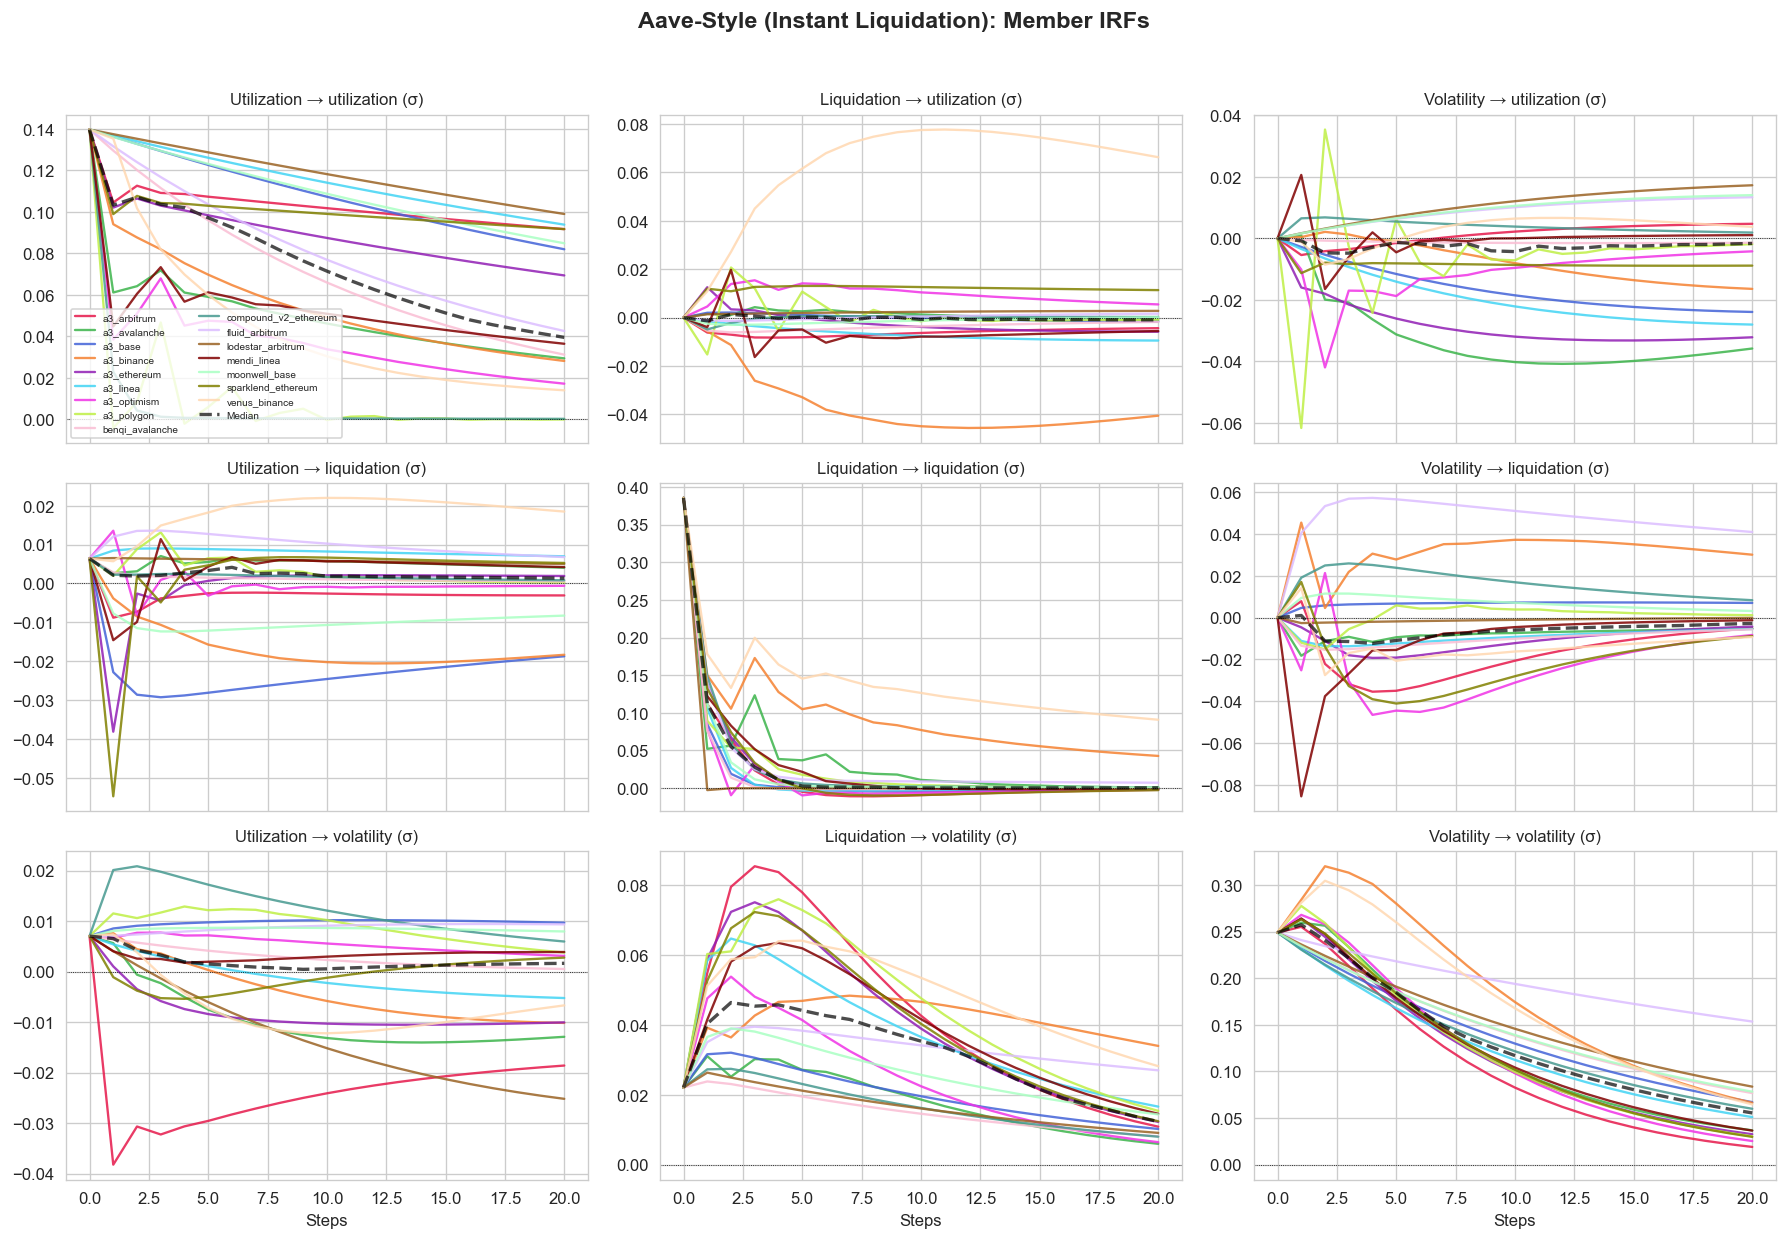

In [21]:
plot_member_irfs(aave_irfs, 'Aave-Style (Instant Liquidation): Member IRFs',
                 save_path='../results/pedroni/2nd_order/mechanism/mechanism_aave_members.png')

### 9b. Member IRFs — Compound V3

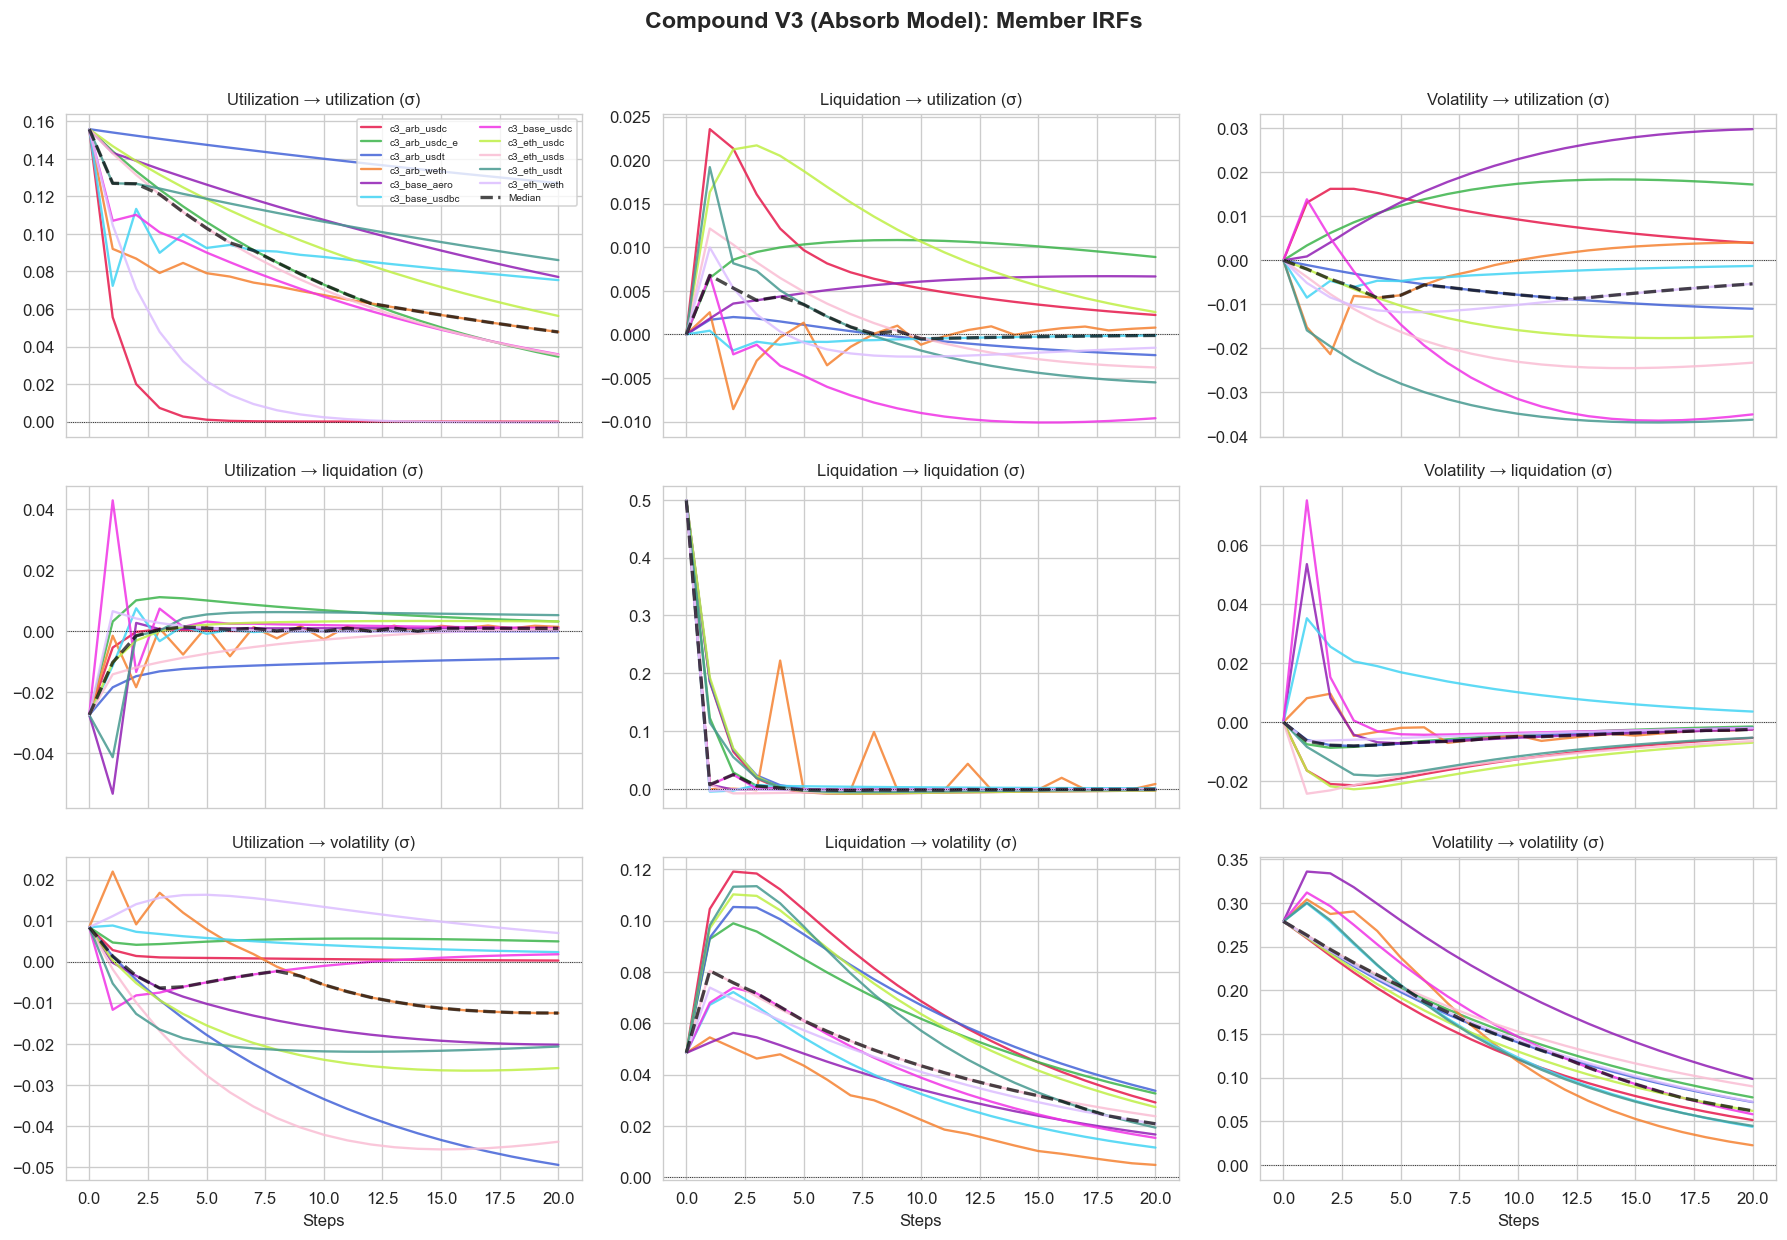

In [22]:
plot_member_irfs(comp_irfs, 'Compound V3 (Absorb Model): Member IRFs',
                 save_path='../results/pedroni/2nd_order/mechanism/mechanism_compound_members.png')

### 9c. Comparison: Median Composite IRFs

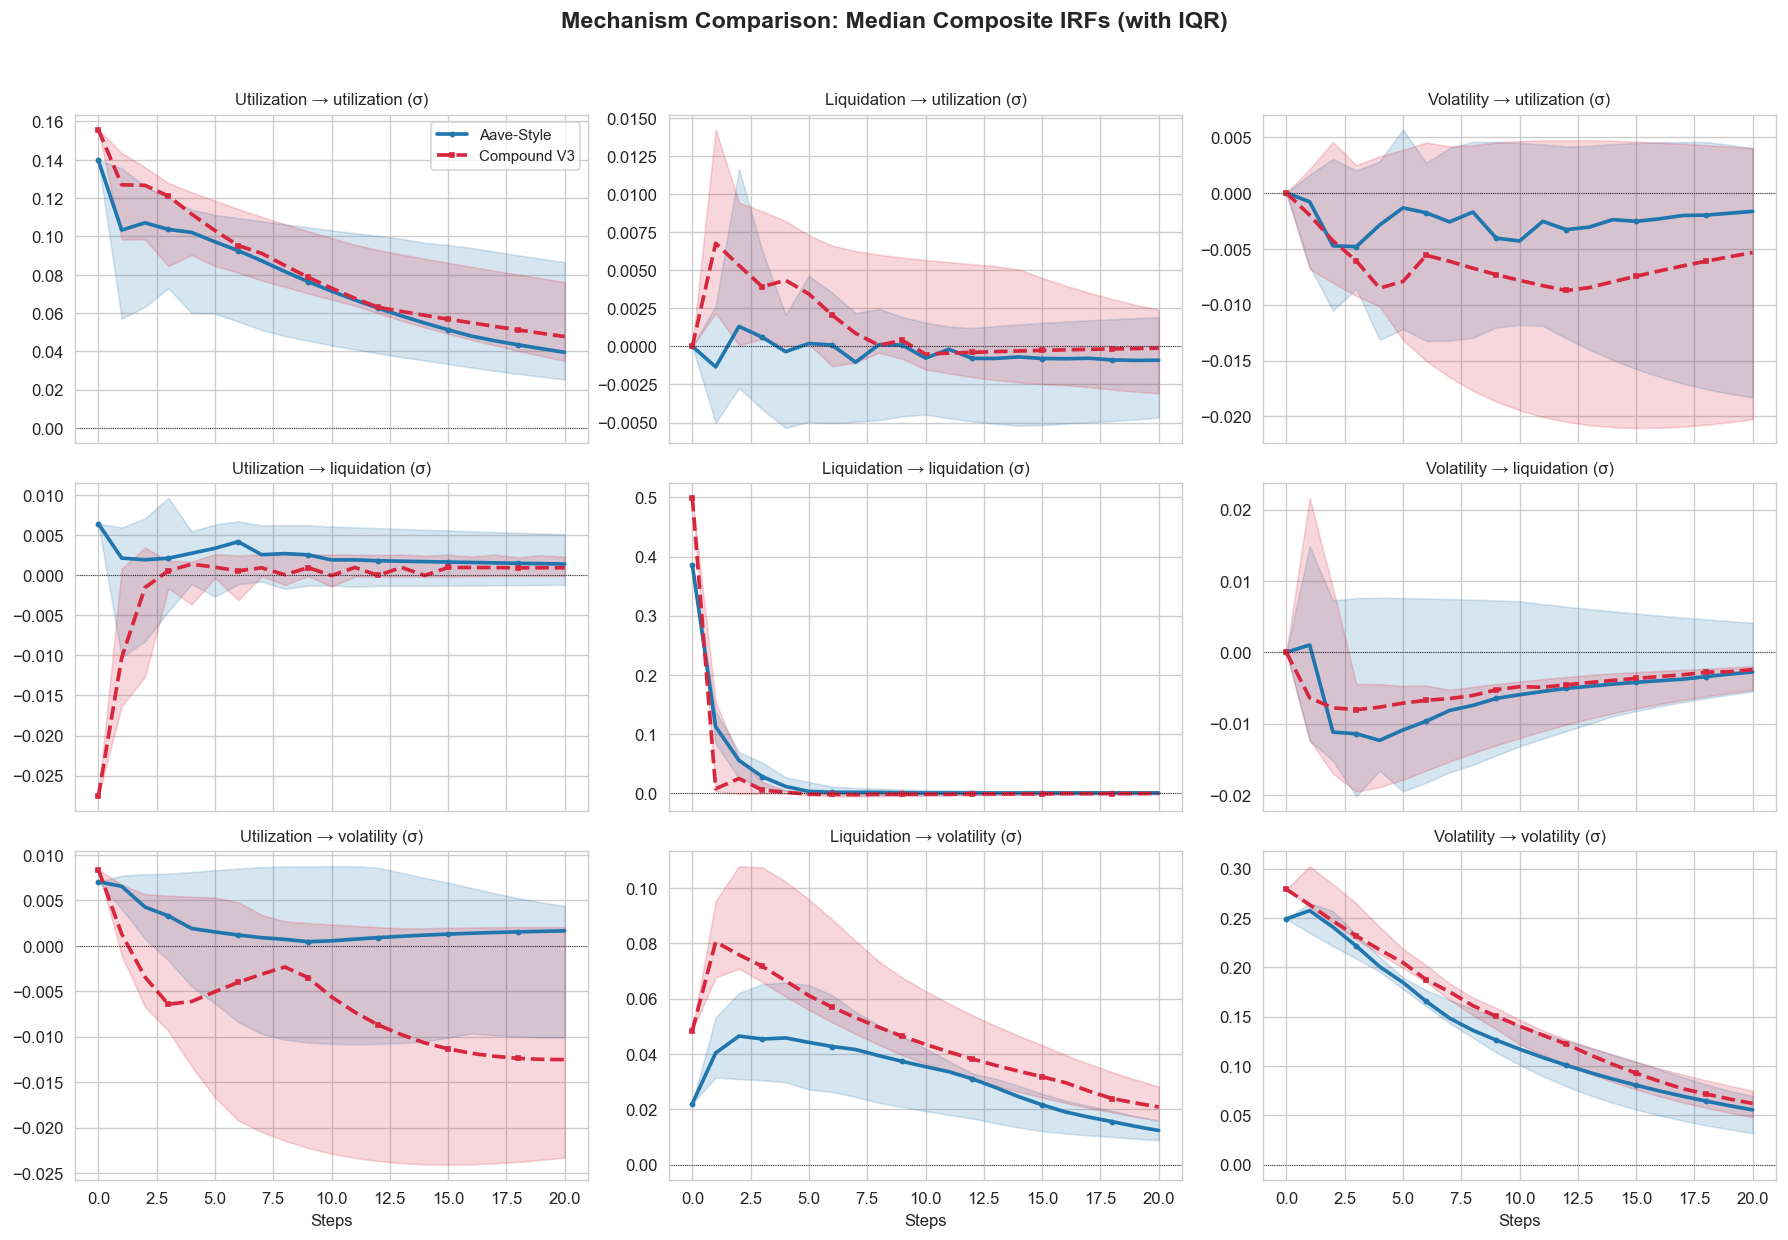

In [23]:
plot_comparison_irfs('Aave-Style', aave_irfs, 'Compound V3', comp_irfs,
                     'Mechanism Comparison: Median Composite IRFs (with IQR)',
                     save_path='../results/pedroni/2nd_order/mechanism/mechanism_comparison.png')

### 9d. Lambda Decomposition — by Mechanism

In [24]:
print('Table 7: Lambda Decomposition \u2014 Aave-Style')
display(lambda_table(aave_irfs).round(4))

print('\nTable 8: Lambda Decomposition \u2014 Compound V3')
display(lambda_table(comp_irfs).round(4))

Table 7: Lambda Decomposition — Aave-Style


,Member,λ_util,λ_liq,λ_vol
0,aave_v3_arbitrum,0.2384,1.5249,1.1765
1,aave_v3_avalanche,1.3939,0.4661,1.1330
2,aave_v3_base,0.2954,0.9864,1.2245
3,aave_v3_binance,0.5455,0.6601,0.5681
4,aave_v3_ethereum,0.1682,1.4533,1.2331
5,aave_v3_linea,0.2105,1.5342,1.0605
6,aave_v3_optimism,1.2475,1.3459,1.3292
7,aave_v3_polygon,2.8370,1.5984,1.0938
8,benqi_lending_avalanche,0.5685,0.5270,1.0326
9,compound_v2_ethereum,2.7955,0.8857,0.3140



Table 8: Lambda Decomposition — Compound V3


,Member,λ_util,λ_liq,λ_vol
0,compound_v3_arb_usdc,2.8887,1.3962,1.1017
1,compound_v3_arb_usdc_e,0.8759,1.2000,0.8946
2,compound_v3_arb_usdt,0.0640,1.3071,0.7928
3,compound_v3_arb_weth,0.0935,0.2550,1.1093
4,compound_v3_base_aero,0.0115,0.2780,0.6435
5,compound_v3_base_usdbc,0.3759,0.7886,1.1748
6,compound_v3_base_usdc,1.1335,0.7812,1.0105
7,compound_v3_eth_usdc,0.7385,1.3155,1.0216
8,compound_v3_eth_usds,0.7100,1.1682,0.6518
9,compound_v3_eth_usdt,0.5347,1.3858,1.0411


### 9e. Cumulative IRF Comparison — Mechanism

In [25]:
cum_aave = cumulative_irf_table(aave_irfs, label='Aave-Style')
cum_comp = cumulative_irf_table(comp_irfs, label='Compound V3')
cum_mech = pd.concat([cum_aave, cum_comp])

print('Table 9: Cumulative IRF Comparison \u2014 Mechanism (h=10)')
mech_h10 = cum_mech[cum_mech['Horizon'] == 10].pivot_table(
    index=['Response', 'Shock'], columns='Subsample', values='Cumulative IRF'
)
mech_h10['Ratio (Aave/Compound)'] = mech_h10['Aave-Style'] / mech_h10['Compound V3']
mech_h10.round(6)

Table 9: Cumulative IRF Comparison — Mechanism (h=10)


Subsample                Aave-Style  Compound V3  Ratio (Aave/Compound)
Response    Shock                                                      
liquidation Liquidation    0.599195     0.525287               1.140699
            Utilization    0.032386    -0.034180              -0.947522
            Volatility    -0.082423    -0.066320               1.242804
utilization Liquidation   -0.001119     0.026651              -0.041971
            Utilization    1.062386     1.168079               0.909516
            Volatility    -0.028989    -0.062372               0.464777
volatility  Liquidation    0.440576     0.653280               0.674406
            Utilization    0.028284    -0.030003              -0.942702
            Volatility     2.046767     2.257323               0.906723

### 9f. Key Cross-Variable IRFs — Mechanism

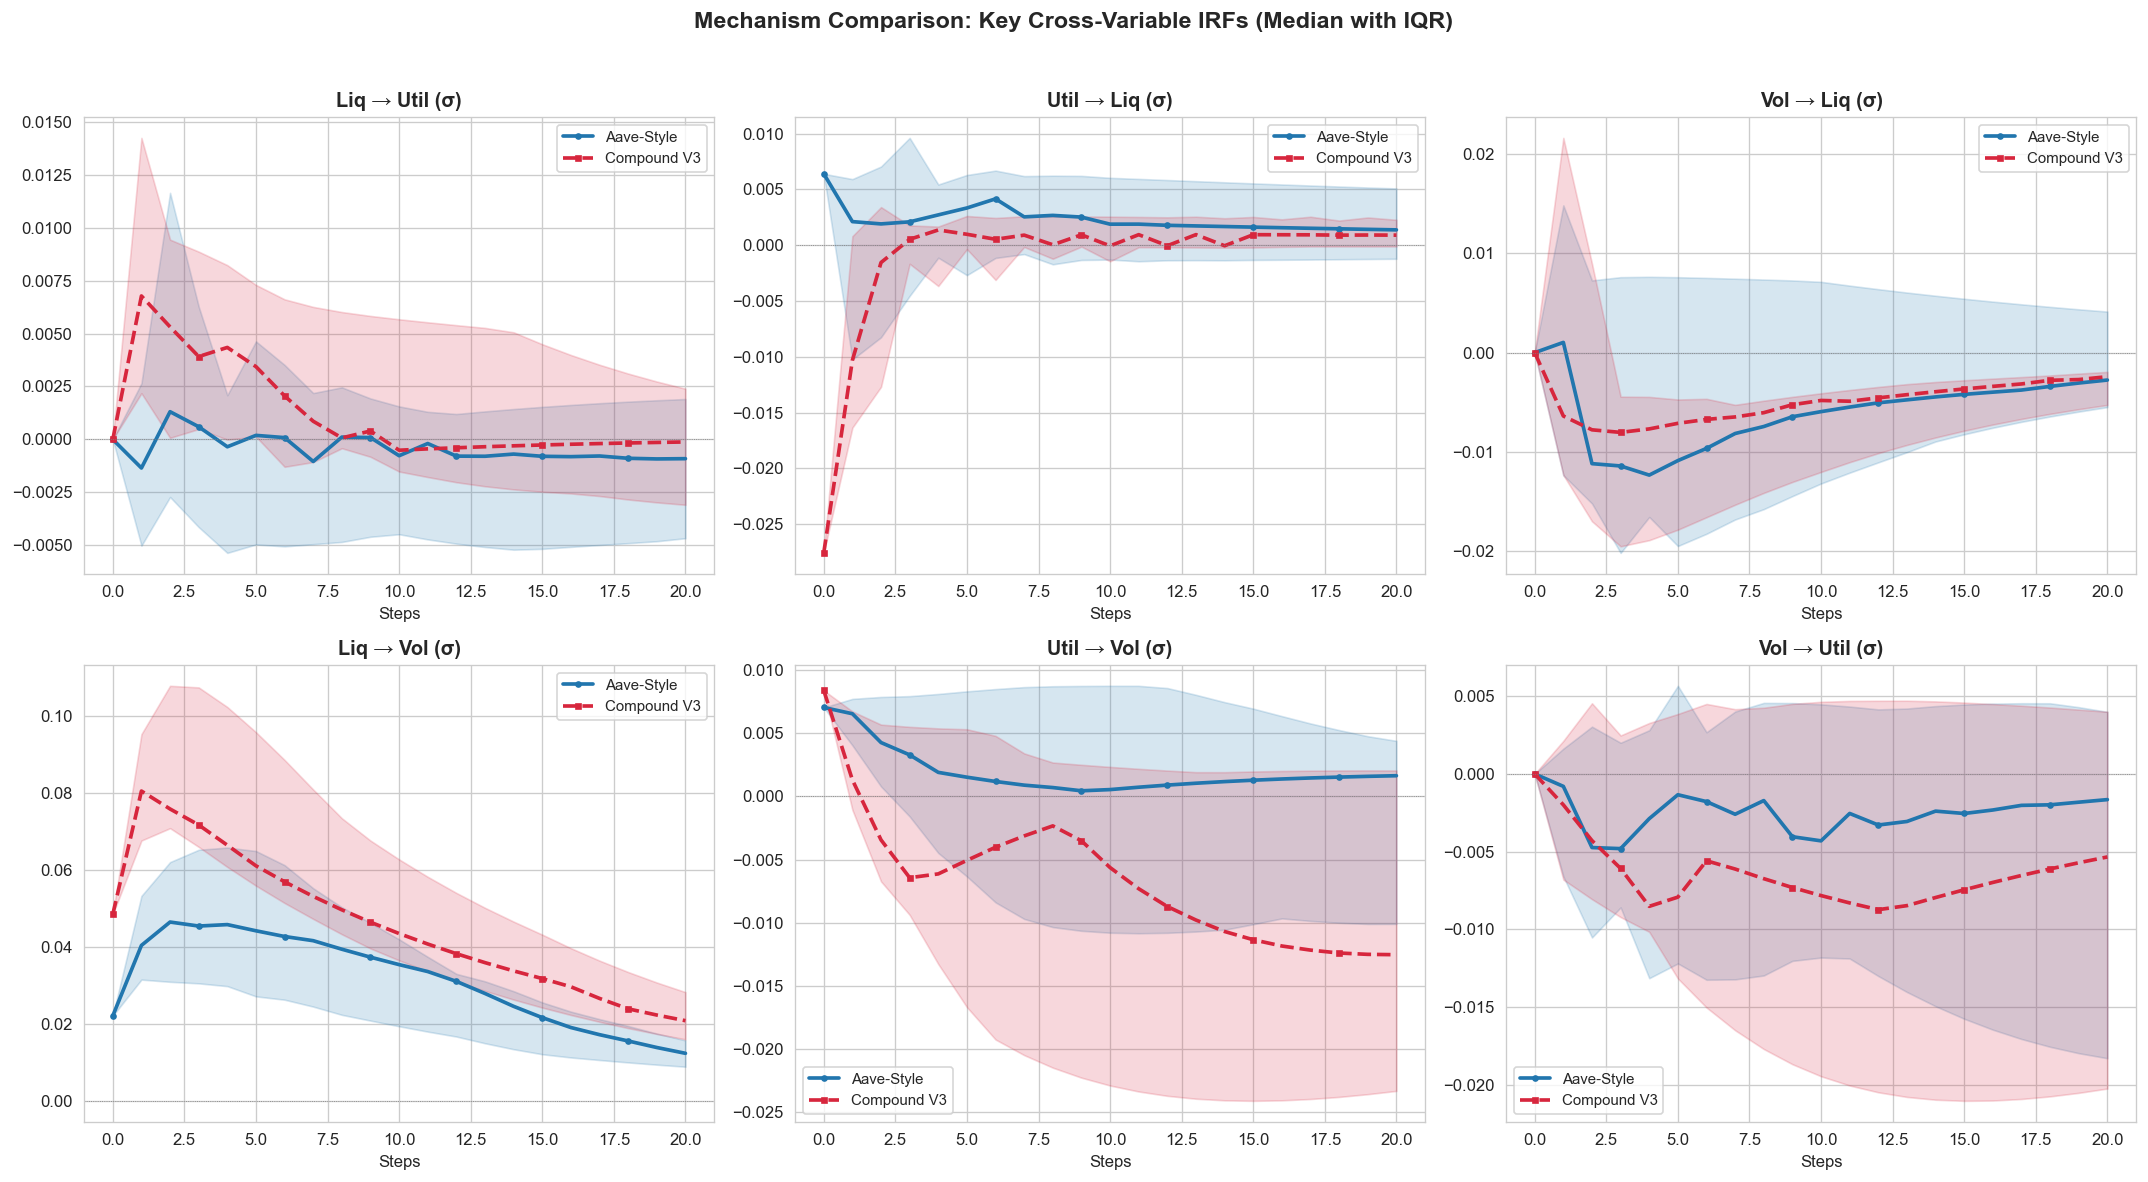

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
med_a = compute_median_irf(aave_irfs)
med_c = compute_median_irf(comp_irfs)
iqr_a_lo, iqr_a_hi = compute_iqr(aave_irfs)
iqr_c_lo, iqr_c_hi = compute_iqr(comp_irfs)
steps = np.arange(med_a.shape[0])

for idx, (resp, shock, ri, si, label) in enumerate(key_paths):
    ax = axes[idx // 3, idx % 3]
    ax.plot(steps, med_a[:, ri, si], color='#2176AE', linewidth=2.2,
            label='Aave-Style', marker='o', markersize=3, markevery=3)
    ax.plot(steps, med_c[:, ri, si], color='#D7263D', linewidth=2.2,
            linestyle='--', label='Compound V3', marker='s', markersize=3, markevery=3)
    if iqr_a_lo is not None:
        ax.fill_between(steps, iqr_a_lo[:, ri, si], iqr_a_hi[:, ri, si],
                         alpha=0.18, color='#2176AE')
    if iqr_c_lo is not None:
        ax.fill_between(steps, iqr_c_lo[:, ri, si], iqr_c_hi[:, ri, si],
                         alpha=0.18, color='#D7263D')
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Steps')

fig.suptitle('Mechanism Comparison: Key Cross-Variable IRFs (Median with IQR)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../results/pedroni/2nd_order/mechanism/mechanism_key_irfs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Chain Comparison: Ethereum L1 vs Arbitrum L2 vs Base L2

In [27]:
eth_irfs, eth_out = run_pedroni(panel[panel['csu'].isin(ETHEREUM_L1_CSUS)], 'Ethereum L1')
arb_irfs, arb_out = run_pedroni(panel[panel['csu'].isin(ARBITRUM_L2_CSUS)], 'Arbitrum L2')
base_irfs, base_out = run_pedroni(panel[panel['csu'].isin(BASE_L2_CSUS)], 'Base L2')


--- Ethereum L1: 7 members, 3693 obs ---
Transformation matrix M:
[[0.22799846 0.         0.        ]
 [0.02074682 0.61076786 0.        ]
 [0.00337188 0.03049096 0.25747286]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, fr

/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/

  Estimated: 7/7 members

--- Arbitrum L2: 7 members, 3788 obs ---
Transformation matrix M:
[[ 0.17267582  0.          0.        ]
 [-0.04252653  0.52986333  0.        ]
 [-0.00059144  0.04751681  0.24853625]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis

/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library

  Estimated: 7/7 members

--- Base L2: 6 members, 3186 obs ---
Transformation matrix M:
[[ 1.63108592e-01  0.00000000e+00  0.00000000e+00]
 [-4.98359772e-02  6.37608726e-01  0.00000000e+00]
 [-1.88297611e-04  1.85371186e-02  3.18121540e-01]] 



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Version

/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/lewisschrock/Desktop/Academics/thesis_v2.10/code/pedroni_svar/panelSVAR.py:123: RuntimeWarning: invalid value encountered in sqrt
  idio_ir = multiply_by_matrix(member_output.ir, np.sqrt(np.identity(input.size)-Lambda**2))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._i

SVAR failed for compound_v3_base_weth: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.
  Estimated: 5/6 members


### 10a. Member IRFs — Ethereum L1

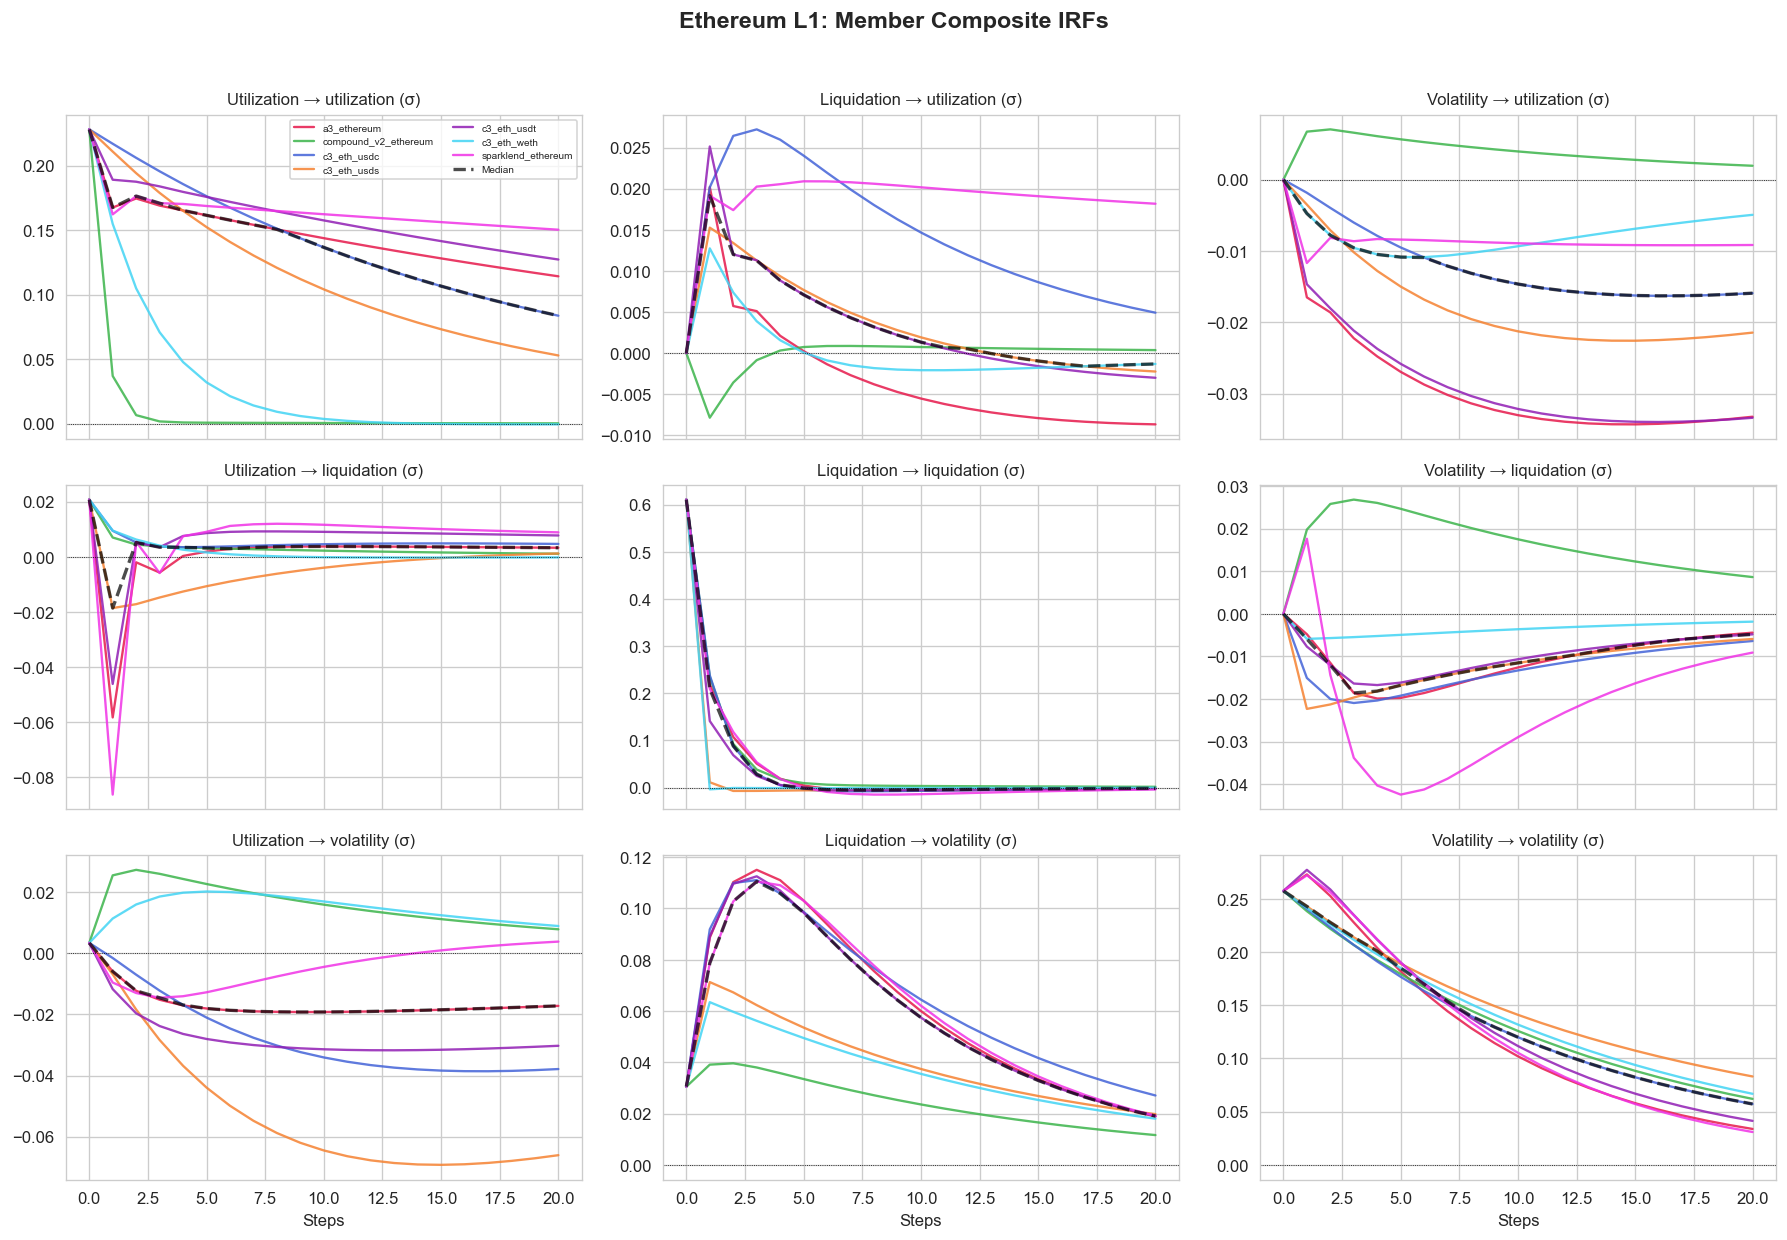

In [28]:
plot_member_irfs(eth_irfs, 'Ethereum L1: Member Composite IRFs',
                 save_path='../results/pedroni/2nd_order/chain/chain_ethereum_members.png')

### 10b. Member IRFs — Arbitrum L2

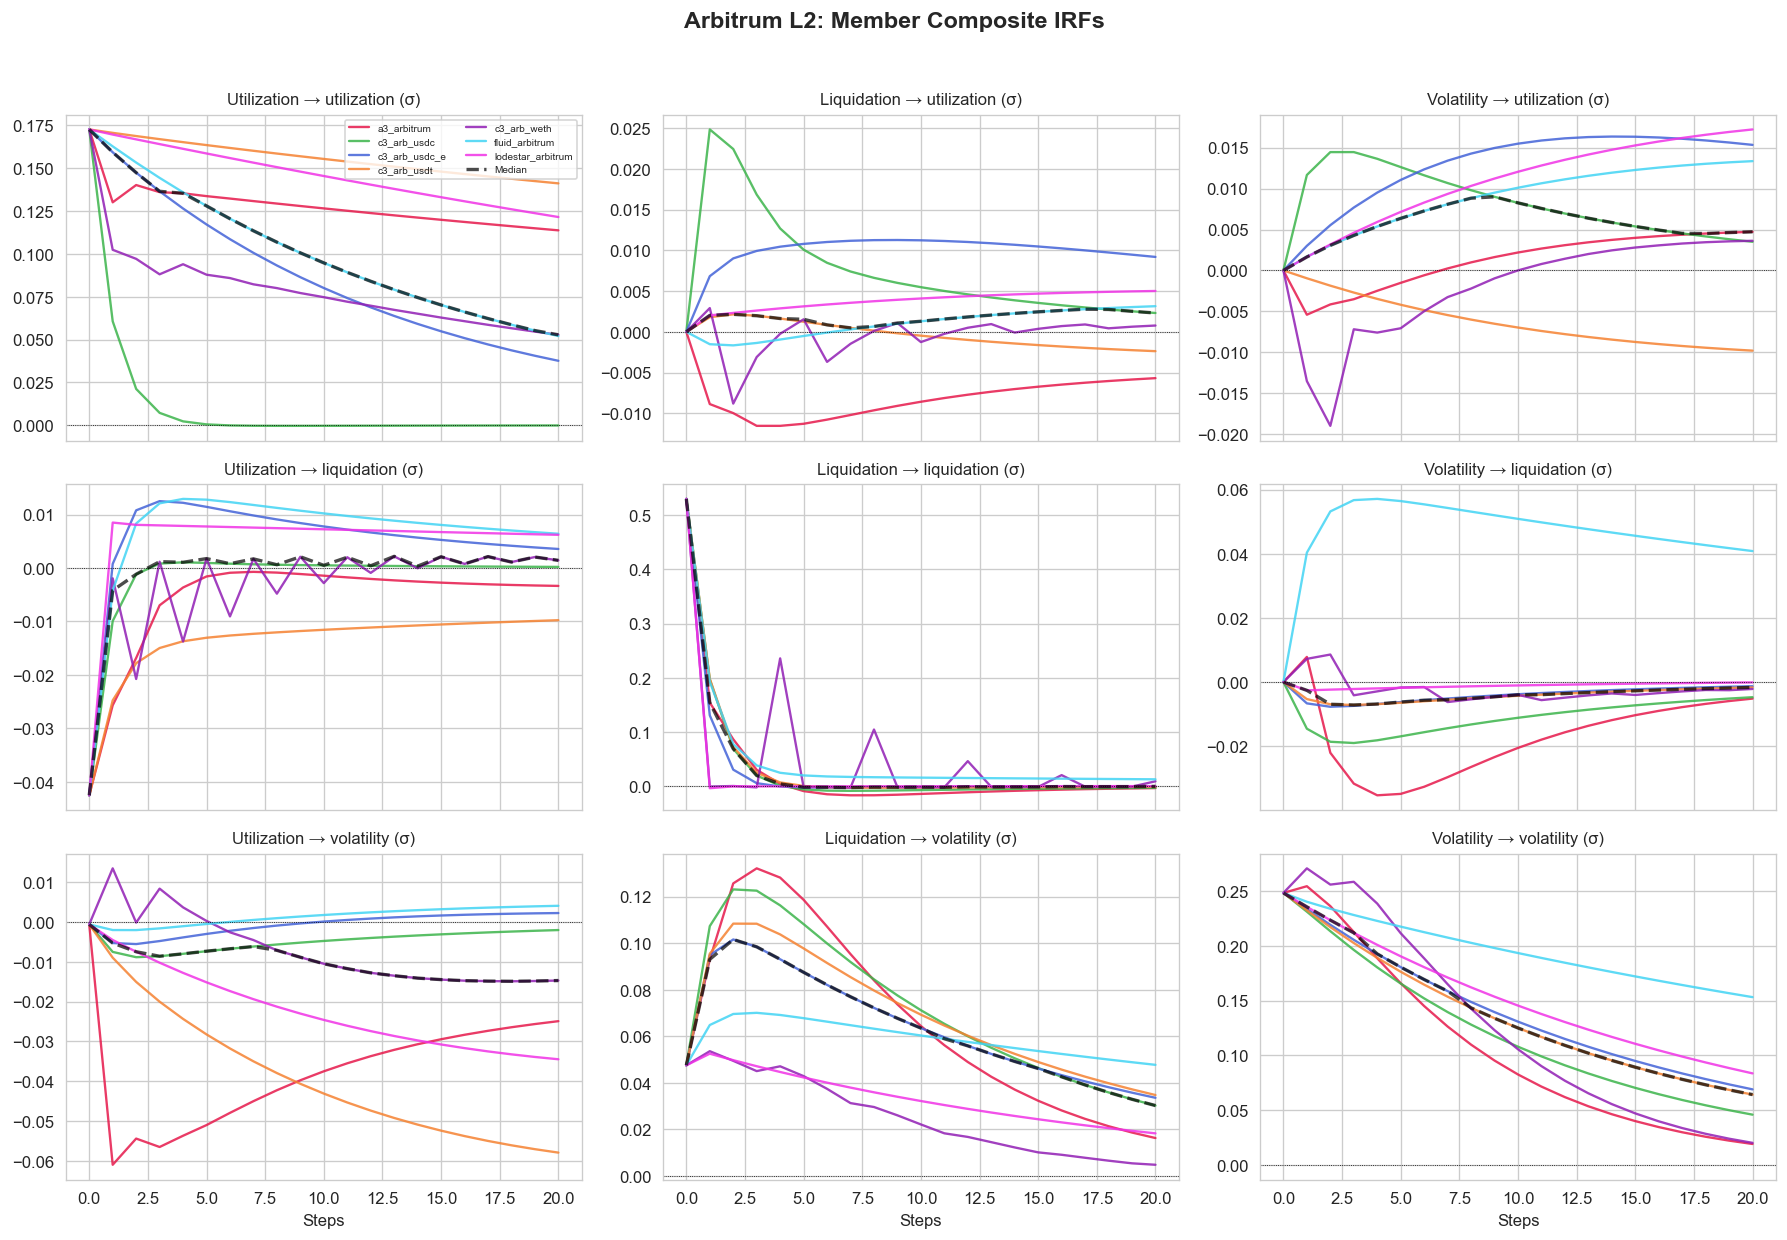

In [29]:
plot_member_irfs(arb_irfs, 'Arbitrum L2: Member Composite IRFs',
                 save_path='../results/pedroni/2nd_order/chain/chain_arbitrum_members.png')

### 10c. Member IRFs — Base L2

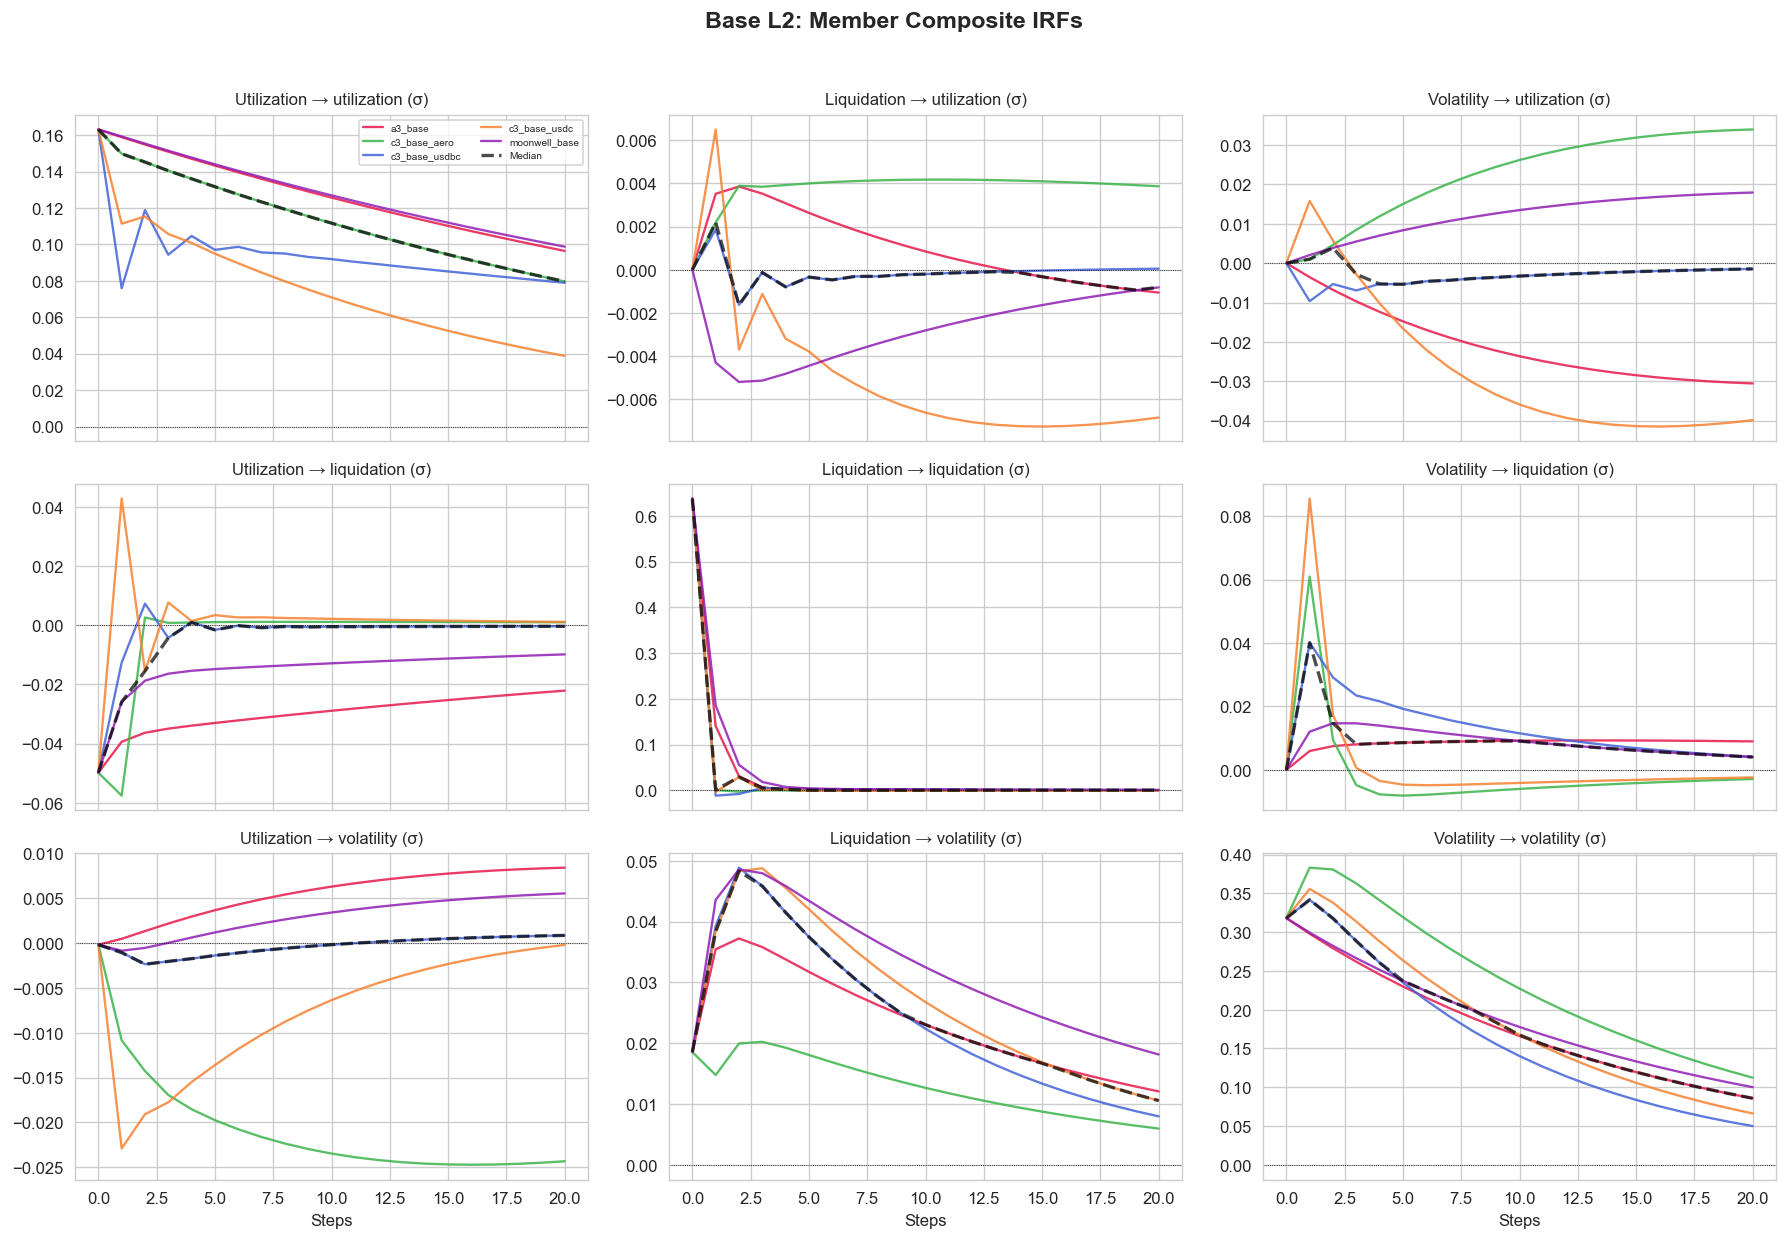

In [30]:
plot_member_irfs(base_irfs, 'Base L2: Member Composite IRFs',
                 save_path='../results/pedroni/2nd_order/chain/chain_base_members.png')

### 10d. Comparison: Ethereum L1 vs Arbitrum L2

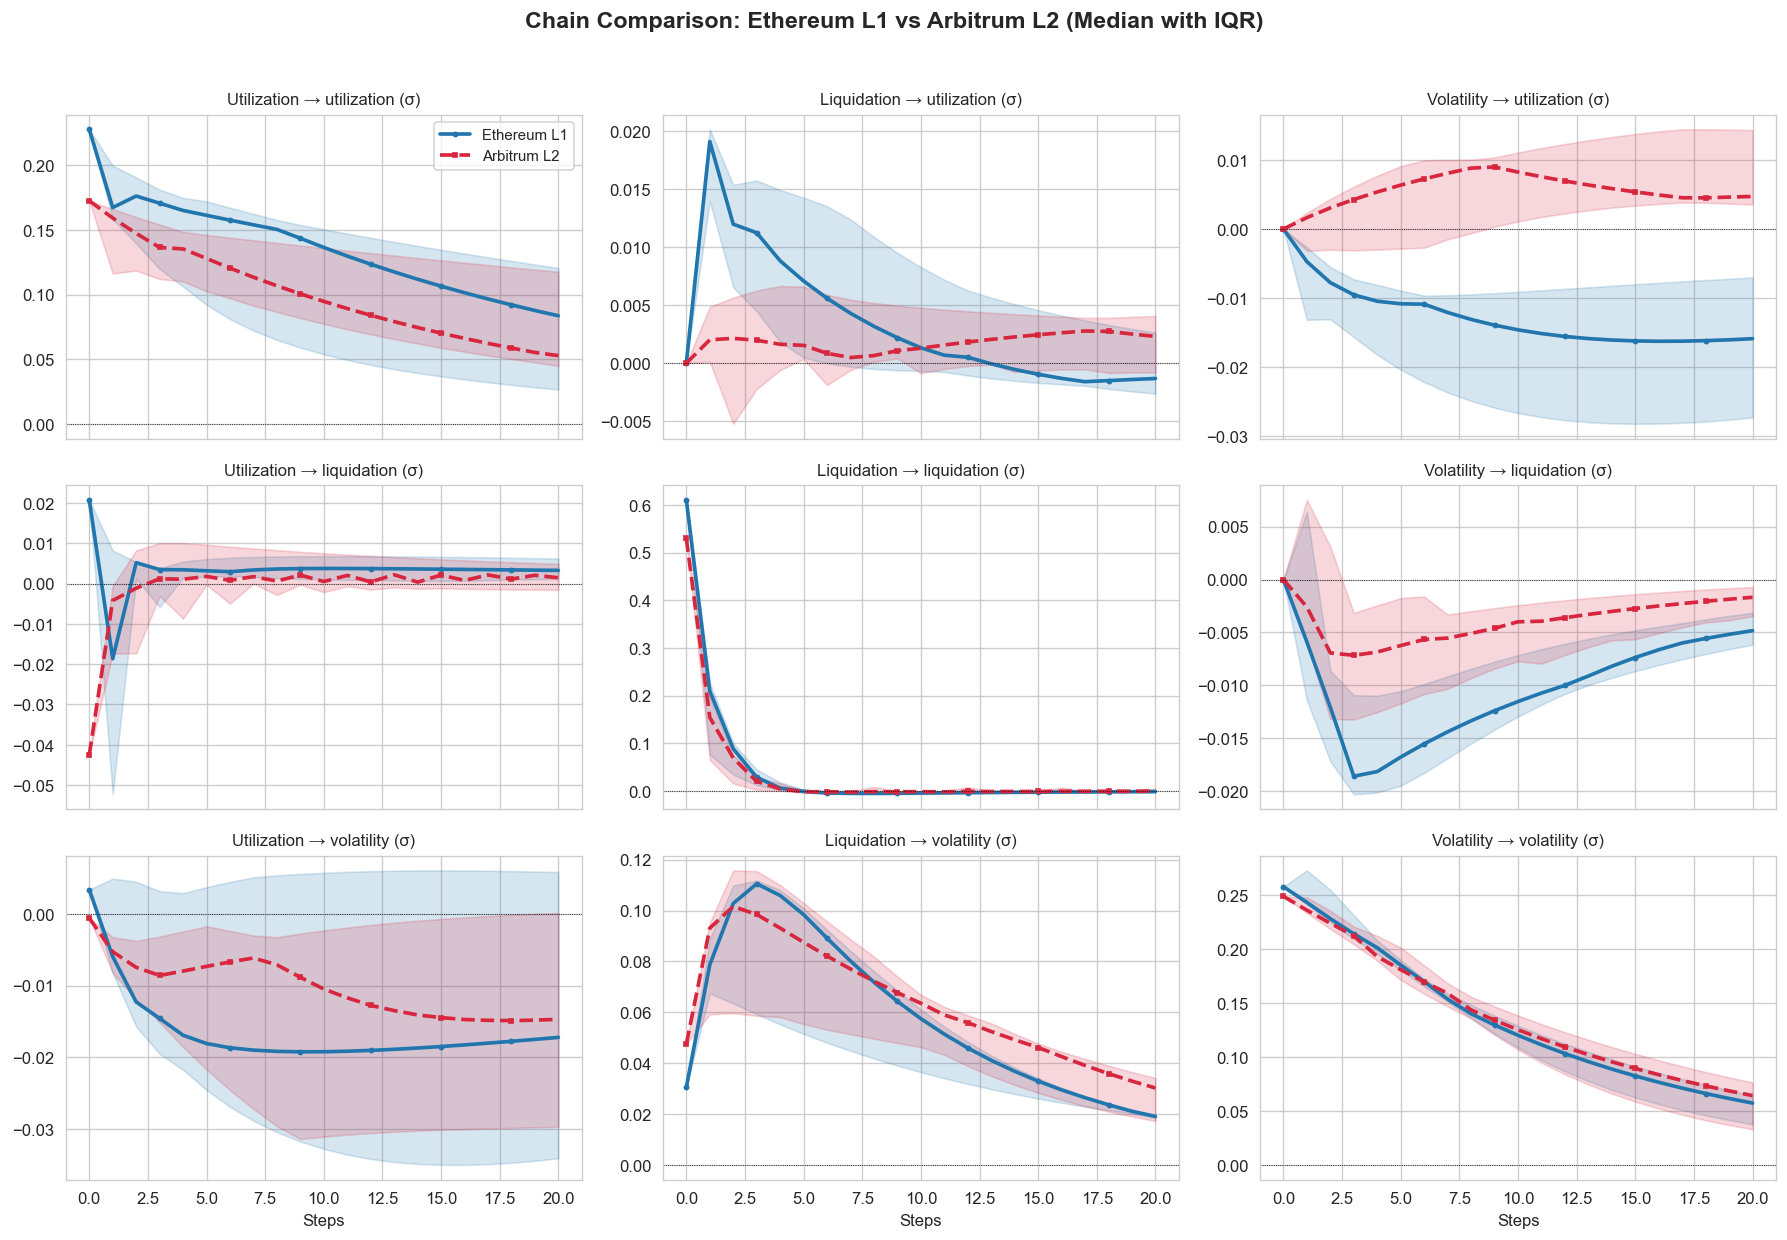

In [31]:
plot_comparison_irfs('Ethereum L1', eth_irfs, 'Arbitrum L2', arb_irfs,
                     'Chain Comparison: Ethereum L1 vs Arbitrum L2 (Median with IQR)',
                     save_path='../results/pedroni/2nd_order/chain/chain_eth_vs_arb.png')

### 10e. Comparison: Ethereum L1 vs Base L2

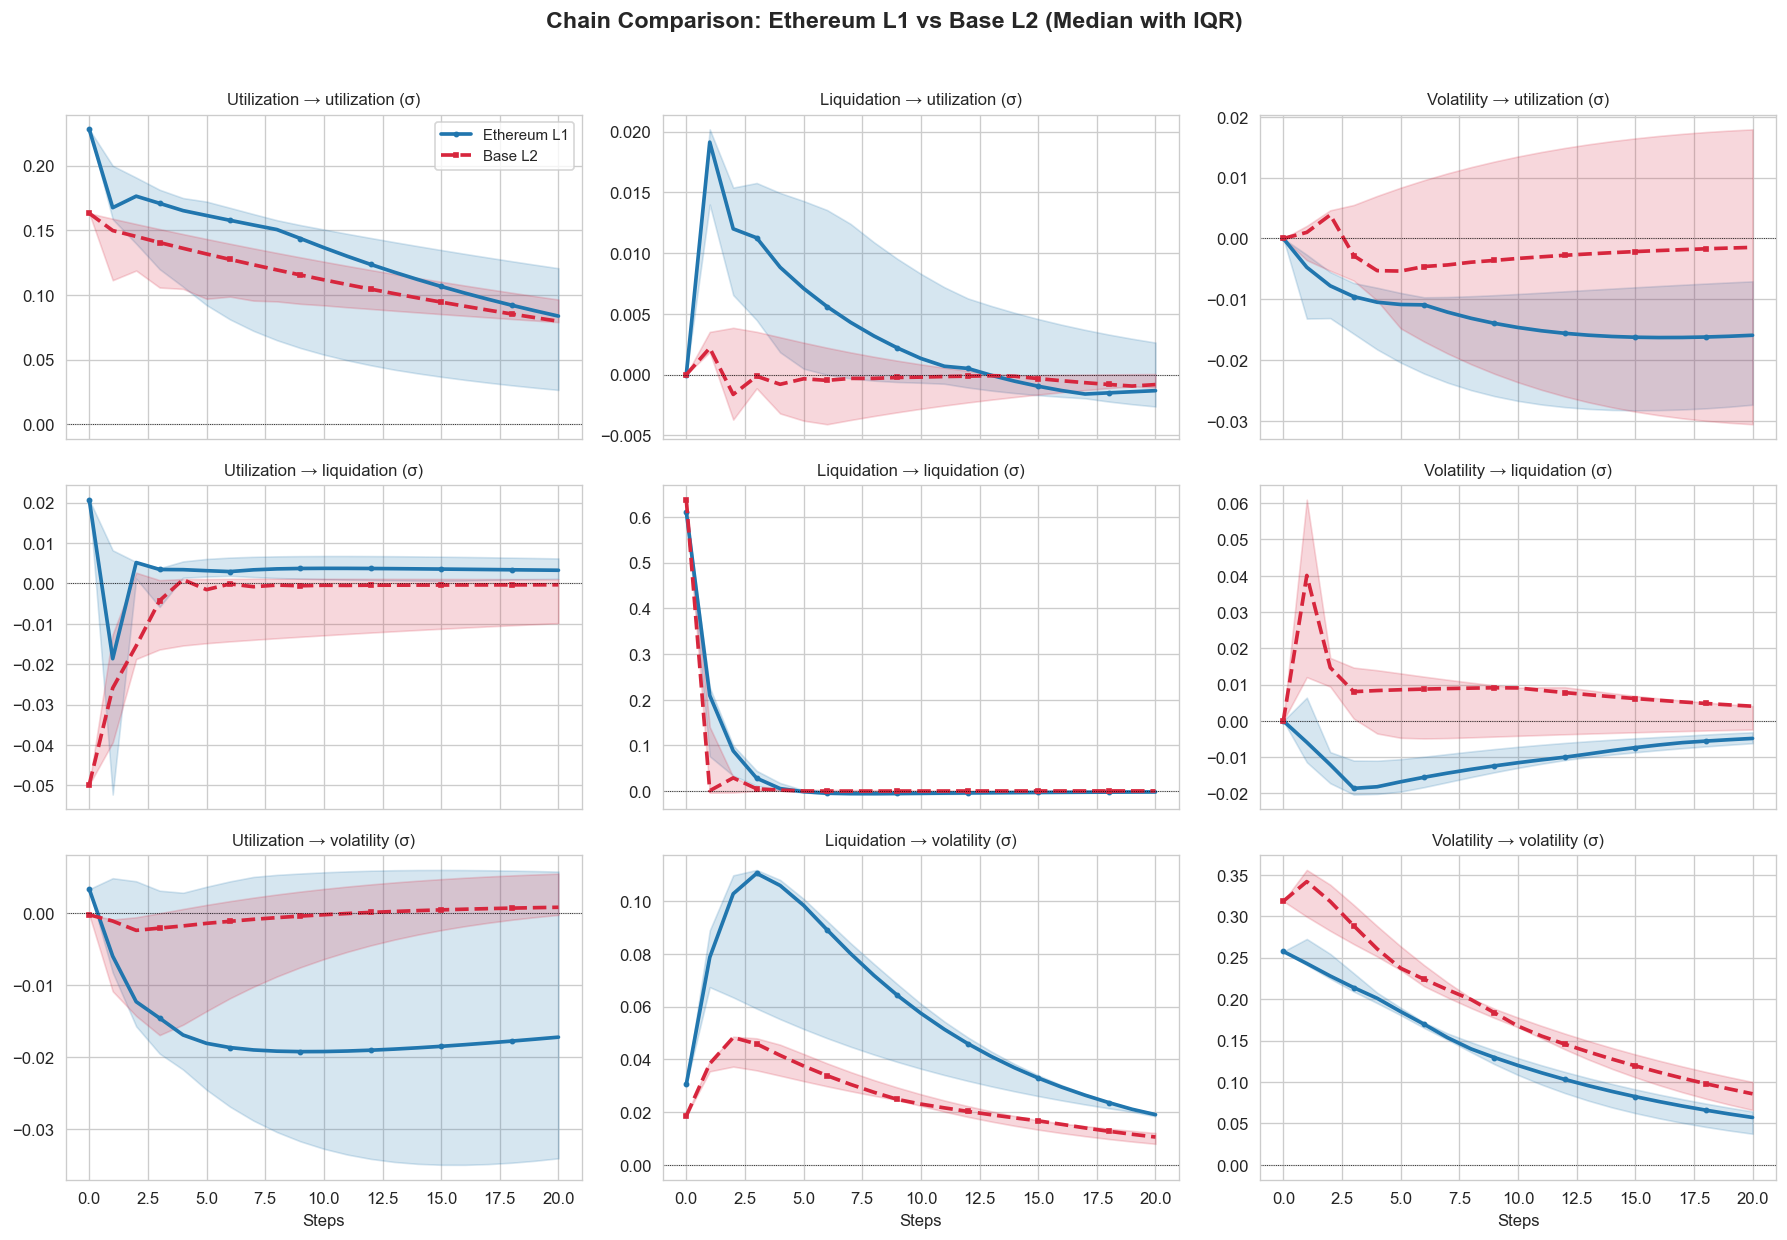

In [32]:
plot_comparison_irfs('Ethereum L1', eth_irfs, 'Base L2', base_irfs,
                     'Chain Comparison: Ethereum L1 vs Base L2 (Median with IQR)',
                     save_path='../results/pedroni/2nd_order/chain/chain_eth_vs_base.png')

### 10f. Lambda Decomposition — by Chain

In [33]:
print('Table 10: Lambda Decomposition \u2014 Ethereum L1')
display(lambda_table(eth_irfs).round(4))

print('\nTable 11: Lambda Decomposition \u2014 Arbitrum L2')
display(lambda_table(arb_irfs).round(4))

print('\nTable 12: Lambda Decomposition \u2014 Base L2')
display(lambda_table(base_irfs).round(4))

Table 10: Lambda Decomposition — Ethereum L1


,Member,λ_util,λ_liq,λ_vol
0,aave_v3_ethereum,0.2721,0.9684,1.1932
1,compound_v2_ethereum,2.6427,0.7906,0.4358
2,compound_v3_eth_usdc,0.4155,1.1481,1.1004
3,compound_v3_eth_usds,0.5307,1.0754,0.6561
4,compound_v3_eth_usdt,0.3650,1.2178,1.1123
5,compound_v3_eth_weth,1.6633,0.7096,1.1561
6,sparklend_ethereum,0.2559,1.0127,1.1519
7,MEDIAN,0.4155,1.0127,1.1123



Table 11: Lambda Decomposition — Arbitrum L2


,Member,λ_util,λ_liq,λ_vol
0,aave_v3_arbitrum,0.1480,1.0560,1.1764
1,compound_v3_arb_usdc,3.7475,1.3105,1.1990
2,compound_v3_arb_usdc_e,0.7024,1.0664,0.9940
3,compound_v3_arb_usdt,0.0544,1.1750,0.9050
4,compound_v3_arb_weth,0.2159,0.4798,1.2064
5,fluid_lending_arbitrum,0.4314,0.6470,0.4175
6,lodestar_lending_arbitrum,0.1264,0.7631,0.7916
7,MEDIAN,0.2159,1.0560,0.9940



Table 12: Lambda Decomposition — Base L2


,Member,λ_util,λ_liq,λ_vol
0,aave_v3_base,0.5346,1.1308,1.0521
1,compound_v3_base_aero,0.3102,0.5457,0.6183
2,compound_v3_base_usdbc,0.4712,1.0352,1.0829
3,compound_v3_base_usdc,1.3899,1.0915,0.9721
4,moonwell_lending_base,0.4760,1.0308,0.9868
5,MEDIAN,0.4760,1.0352,0.9868


### 10g. Cumulative IRF Comparison — Chain

In [34]:
cum_eth = cumulative_irf_table(eth_irfs, label='Ethereum L1')
cum_arb = cumulative_irf_table(arb_irfs, label='Arbitrum L2')
cum_base = cumulative_irf_table(base_irfs, label='Base L2')
cum_chain = pd.concat([cum_eth, cum_arb, cum_base])

print('Table 13: Cumulative IRF Comparison \u2014 Chain (h=10)')
chain_h10 = cum_chain[cum_chain['Horizon'] == 10].pivot_table(
    index=['Response', 'Shock'], columns='Subsample', values='Cumulative IRF'
)
chain_h10.round(6)

Table 13: Cumulative IRF Comparison — Chain (h=10)


Subsample                Arbitrum L2   Base L2  Ethereum L1
Response    Shock                                          
liquidation Liquidation     0.764050  0.676864     0.916270
            Utilization    -0.038161 -0.098414     0.034647
            Volatility     -0.054631  0.124683    -0.138645
utilization Liquidation     0.013680 -0.002235     0.074933
            Utilization     1.415710  1.463453     1.811614
            Volatility      0.062160 -0.028337    -0.108157
volatility  Liquidation     0.883652  0.369738     0.889505
            Utilization    -0.076559 -0.011873    -0.159765
            Volatility      2.024030  2.749732     2.040491

---
## 11. Export All Results

In [35]:
def irfs_to_csv(member_irfs, path, irf_type='composite'):
    rows = []
    for member, data in member_irfs.items():
        ir = data[irf_type]
        for lg in range(ir.shape[0]):
            for i, var in enumerate(VARIABLE_ORDER):
                for j, shock in enumerate(SHOCKS):
                    rows.append({'member': member, 'step': lg, 'response': var,
                                 'shock': shock, 'value': ir[lg, i, j]})
    pd.DataFrame(rows).to_csv(path, index=False)

results_dir = Path('../results/pedroni')
dir_1st = results_dir / '1st_order'
dir_arch = results_dir / '2nd_order' / 'architecture'
dir_mech = results_dir / '2nd_order' / 'mechanism'
dir_chain = results_dir / '2nd_order' / 'chain'
for d in [dir_1st, dir_arch, dir_mech, dir_chain]:
    d.mkdir(parents=True, exist_ok=True)

# 1st order
stats_df.to_csv(dir_1st / 'table1_summary_stats.csv', index=False)
lambda_table(full_irfs).to_csv(dir_1st / 'table2_lambda_full.csv', index=False)
cum_full.to_csv(dir_1st / 'table3_cum_irf_full.csv', index=False)
irfs_to_csv(full_irfs, dir_1st / 'irfs_full_composite.csv')
irfs_to_csv(full_irfs, dir_1st / 'irfs_full_common.csv', 'common')
irfs_to_csv(full_irfs, dir_1st / 'irfs_full_idiosyncratic.csv', 'idiosyncratic')

# 2nd order: architecture
lambda_table(pooled_irfs).to_csv(dir_arch / 'table4_lambda_pooled.csv', index=False)
lambda_table(isolated_irfs).to_csv(dir_arch / 'table5_lambda_isolated.csv', index=False)
cum_arch.to_csv(dir_arch / 'table6_cum_irf_architecture.csv', index=False)
irfs_to_csv(pooled_irfs, dir_arch / 'irfs_pooled_composite.csv')
irfs_to_csv(isolated_irfs, dir_arch / 'irfs_isolated_composite.csv')

# 2nd order: mechanism
lambda_table(aave_irfs).to_csv(dir_mech / 'table7_lambda_aave.csv', index=False)
lambda_table(comp_irfs).to_csv(dir_mech / 'table8_lambda_compound.csv', index=False)
cum_mech.to_csv(dir_mech / 'table9_cum_irf_mechanism.csv', index=False)
irfs_to_csv(aave_irfs, dir_mech / 'irfs_aave_composite.csv')
irfs_to_csv(comp_irfs, dir_mech / 'irfs_compound_composite.csv')

# 2nd order: chain
lambda_table(eth_irfs).to_csv(dir_chain / 'table10_lambda_ethereum.csv', index=False)
lambda_table(arb_irfs).to_csv(dir_chain / 'table11_lambda_arbitrum.csv', index=False)
lambda_table(base_irfs).to_csv(dir_chain / 'table12_lambda_base.csv', index=False)
cum_chain.to_csv(dir_chain / 'table13_cum_irf_chain.csv', index=False)
irfs_to_csv(eth_irfs, dir_chain / 'irfs_ethereum_composite.csv')
irfs_to_csv(arb_irfs, dir_chain / 'irfs_arbitrum_composite.csv')
irfs_to_csv(base_irfs, dir_chain / 'irfs_base_composite.csv')

print(f'All results exported to {results_dir}/')
for d in [dir_1st, dir_arch, dir_mech, dir_chain]:
    print(f'  {d.name}: {len(list(d.glob("*")))} files')

All results exported to ../results/pedroni/
  1st_order: 8 files
  architecture: 9 files
  mechanism: 9 files
  chain: 12 files


## 12. Interpretation Summary

### Methodology
- **Pedroni Panel SVAR** (Pedroni 2013): heterogeneous member-specific VARs with common/idiosyncratic decomposition
- **Cholesky ordering:** utilization → liquidation → volatility
- **Lambda (λ):** measures how much of each member's shock is common vs idiosyncratic
  - λ ≈ 1: shock mostly common (shared across markets)
  - λ ≈ 0: shock mostly idiosyncratic (market-specific)

### Comparisons

**Architecture (Pooled vs Isolated):**
- Pooled architecture (Aave-style) vs isolated risk pools (Compound V3)
- Key question: Does shared liquidity amplify shock transmission?

**Mechanism (Aave-Style vs Compound V3):**
- Instant competitive liquidation vs protocol-absorbed liquidation
- Key question: Does the liquidation mechanism affect volatility spillovers?

**Chain (Ethereum L1 vs Arbitrum/Base L2):**
- High gas cost mainnet vs low gas cost rollups
- Key question: Does chain environment affect cross-market shock commonality?